## $\color{red}{\text{ANALYSIS of M2.0-class flare}}$

---

#### We analyze M2.0-class solar flare (occured on $15/10/2024$ around $18:30\,\rm UT$), which was 

#### observed during the Solar Orbiter Major Flare Watch Campaign.

In [463]:
# we import the necessary modules

# standard libraries
import os
import glob
import warnings
from datetime import datetime

# numerical & data handling
import numpy as np
import pandas as pd

# signal & interpolation
from scipy.stats import pearsonr
from scipy.signal import find_peaks, savgol_filter, butter, filtfilt
from scipy.interpolate import LSQUnivariateSpline
from scipy.ndimage import label as nd_label
from numba import jit
import pywt

# astropy
import astropy.units as u
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import SkyCoord
from astropy.table import Table
from astropy.timeseries import LombScargle

# sunpy
import sunpy.map
from sunpy.net import Fido, attrs as a
from sunpy.map import Map
from sunpy.timeseries import TimeSeries

# stixpy
from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook
from stixpy.product import Product
from stixpy.timeseries.quicklook import QLLightCurve

# sunpy-soar
import sunpy_soar

# plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as pltc
from matplotlib.patches import Rectangle
import matplotlib.animation as animation
import seaborn as sn

# wavelet
from waveletFunctions import wavelet, wave_signif
import waveletFunctions as wf

warnings.filterwarnings("ignore")

### $\color{red}{\text{1.1. STIX}} $

---

#### Here, we retrieve the X-ray data from STIX - we do this just for fun.

In [80]:
stix_data = Fido.search(a.Time("2024-10-15", "2024-10-15"), a.Instrument.stix, a.stix.DataProduct.ql_lightcurve)

In [81]:
stix = Fido.fetch(stix_data)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

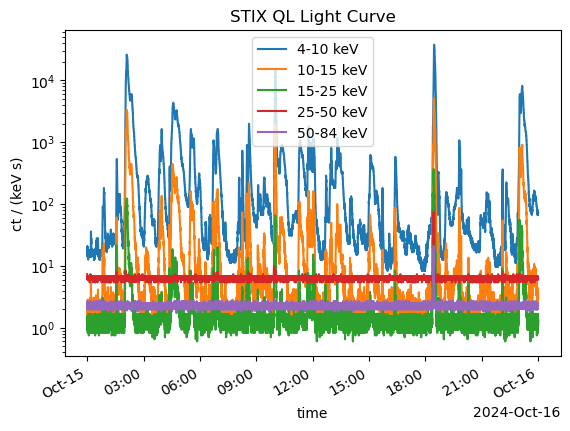

In [114]:
stix_lcs = TimeSeries(stix)
stix_lcs.peek()

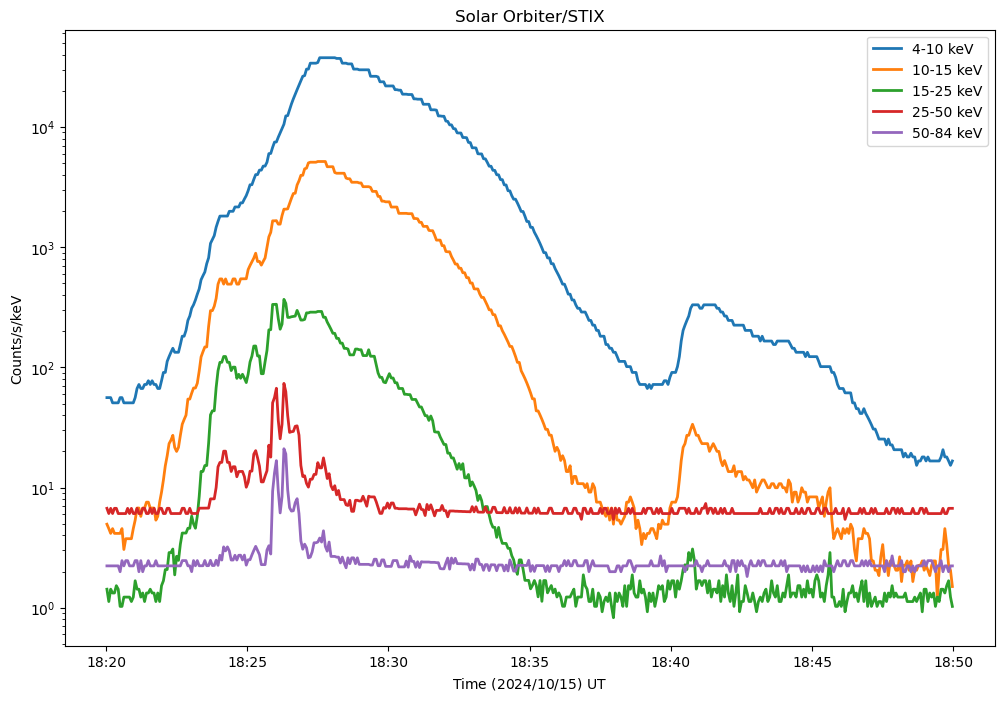

In [333]:
stix_lcs = TimeSeries(stix)
stix_lcs = stix_lcs.to_dataframe().truncate("2024-10-15 18:20", "2024-10-15 18:50")

fig, ax = plt.subplots(figsize=(12, 8))
energy_bands = ['4-10 keV', '10-15 keV', '15-25 keV', '25-50 keV', '50-84 keV']

for band in energy_bands:
    plt.plot(stix_lcs.index, stix_lcs[band], label=band, linewidth=2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel(r'Counts/s/keV')
plt.yscale('log')
plt.title('Solar Orbiter/STIX')
plt.legend()
plt.show()

### $\color{red}{\text{1.2. Compressed Pixel  Data (CPD) from STIX}} $

---

#### This type of files gives us higher time resolution (potentially sub-second), more energy 

#### bins/flexibility and excellent opportunity for detailed QPP analysis. However, issue is 

#### that STIX science data files don't always align perfectly with our requested time range.

In [84]:
sci_query = Fido.search(a.Time("2024-10-15 18:00", "2024-10-15 19:00"), a.Instrument.stix, a.stix.DataType.sci)
print(sci_query)

Results from 1 Provider:

6 Results from the STIXClient:

       Start Time               End Time        Instrument Level DataType  DataProduct  Ver Request ID
----------------------- ----------------------- ---------- ----- -------- ------------- --- ----------
2024-10-15 12:00:00.000 2024-10-15 18:00:04.000       STIX    L1      SCI  sci-xray-cpd V02 2410155003
2024-10-15 18:00:04.000 2024-10-16 00:00:02.000       STIX    L1      SCI  sci-xray-cpd V02 2410152837
2024-10-15 18:16:50.000 2024-10-15 18:39:28.000       STIX    L1      SCI  sci-xray-cpd V02 2410155856
2024-10-15 18:16:57.000 2024-10-15 18:51:33.000       STIX    L1      SCI  sci-xray-cpd V02 2410156916
2024-10-15 16:45:07.000 2024-10-15 22:50:01.000       STIX    L1      SCI sci-xray-spec V02 2410153003
2024-10-15 16:45:07.000 2024-10-15 22:50:01.000       STIX    L1      SCI sci-xray-spec V04 2410153003




In [85]:
cpd_i = [] # exctraction of appropriate CPDs
for i, result in enumerate(sci_query[0]):
    if 'cpd' in result['DataProduct']:
        print(f"CPD file {i}: {result['Start Time']} to {result['End Time']}")
        cpd_i.append(i)

CPD file 0: 2024-10-15 12:00:00.000 to 2024-10-15 18:00:04.000
CPD file 1: 2024-10-15 18:00:04.000 to 2024-10-16 00:00:02.000
CPD file 2: 2024-10-15 18:16:50.000 to 2024-10-15 18:39:28.000
CPD file 3: 2024-10-15 18:16:57.000 to 2024-10-15 18:51:33.000


In [86]:
relevant_files = [i for i in cpd_i if i in [1, 2, 3]]  # further adjustement
sci_files = Fido.fetch(sci_query[0][relevant_files])
cpd_products = []
for file in sci_files:
    if 'cpd' in str(file):
        cpd_products.append(Product(file))

Files Downloaded:   0%|          | 0/3 [00:00<?, ?file/s]

In [152]:
cpd_flare = cpd_products[2]
print("Shapes:") # closer examination of the data structure
print(f"Time: {cpd_flare.data['time'].shape}")
print(f"Counts: {cpd_flare.data['counts'].shape}")
print(f"Detector masks: {cpd_flare.detector_masks}")

time_stix = cpd_flare.data['time']
# time_mpl = time.plot_date
time_res = (time_stix[1] - time_stix[0]).to('s').value
print(f"Time resolution: ~{time_res:.1f} s")
time_stix = time_stix.datetime

Shapes:
Time: (562,)
Counts: (562, 32, 8, 32)
Detector masks: DetectorMasks
    [0...561]: [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]

Time resolution: ~7.0 s


In [630]:
def stix_energy_bands(lcs, time_stix):
    energy_bands = {
        '4-15 keV': np.sum(lcs[:, 0:11], axis=1), 
        '15-25 keV': np.sum(lcs[:, 11:16], axis=1), 
        '25-50 keV': np.sum(lcs[:, 16:17], axis=1), 
        '50-100 keV': np.sum(lcs[:, 17:23], axis=1), 
        '4-50 keV': np.sum(lcs[:, 0:17], axis=1), 
        '25-100 keV': np.sum(lcs[:, 16:23], axis=1)}
    
    stix_lightcurves = {}
    for band_name, counts in energy_bands.items():
        stix_lightcurves[band_name] = pd.Series(counts, index=pd.DatetimeIndex(time_stix), name=band_name)
    return stix_lightcurves

stix_lcs = stix_energy_bands(lcs, time_stix)

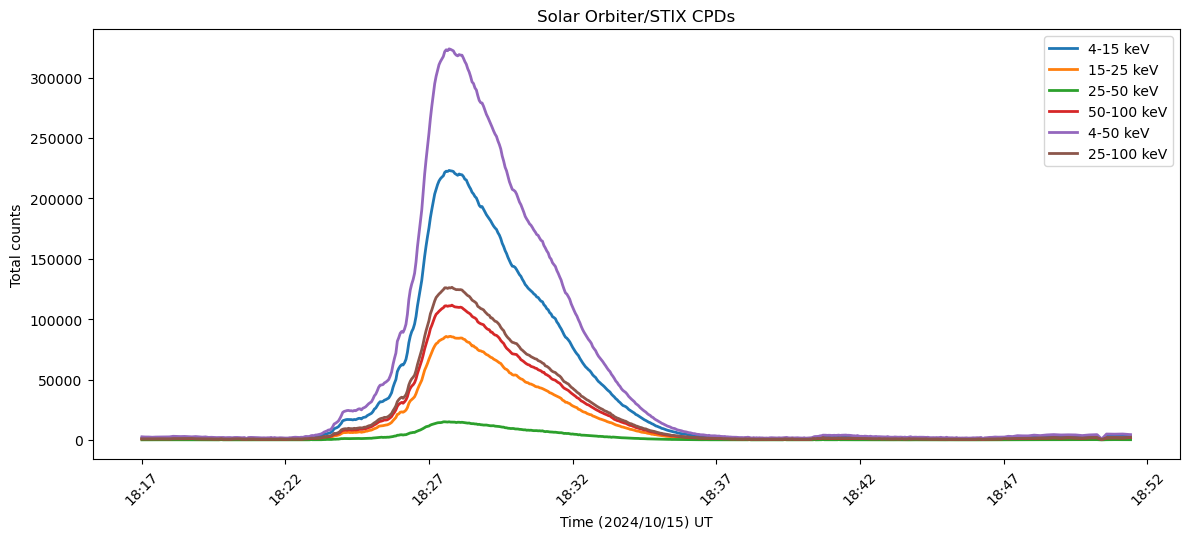

In [348]:
plt.figure(figsize=(12,5.5))
for band_name, lc in stix_lcs.items():
    plt.plot(lc.index, lc.values, label=band_name, linewidth=2)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xticks(rotation=45)
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Total counts')
plt.title('Solar Orbiter/STIX CPDs')
plt.legend()
plt.tight_layout()
plt.show()

#### We normalize and trim STIX $25-50\,\rm keV$ later.

### $\color{red}{\text{2. Soft X-ray (SXR) light curve from GOES}} $

---


#### Here, we have solar SXR fluxes. There are two channels of $(0.5-4)\,\rm Å$ and $(1-8)\,\rm Å$.

In [633]:
res = Fido.search(a.Time("2024-10-15 18:00:00", "2024-10-15 19:00:00"), a.Instrument('XRS'))

2025-08-01 12:36:00 - zeep.wsdl.bindings.soap - WARNING: Forcing soap:address location to HTTPS
2025-08-01 12:36:05 - zeep.wsdl.bindings.soap - WARNING: Forcing soap:address location to HTTPS


In [634]:
files = Fido.fetch(res)
goes = TimeSeries(files)

Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

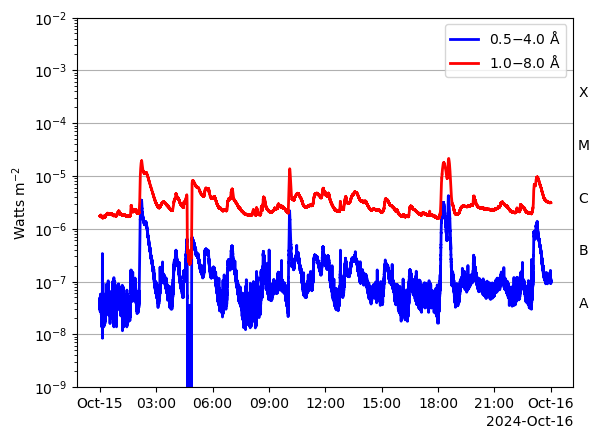

In [635]:
fig, ax = plt.subplots() # retrieval not really okay regarding time range, but we can fix that
goes[0].plot(axes=ax) # we've obtained four datasets
plt.show()

In [637]:
goes_data = goes[0].to_dataframe() 
goes_flare = goes_data.truncate("2024-10-15 18:00:00", "2024-10-15 20:30:00")

print(f"Peak XRSB flux: {goes_flare['xrsb'].max():.2e} W/m²")
print(f"Peak XRSA flux: {goes_flare['xrsa'].max():.2e} W/m²")

xrsb_peak = goes_flare['xrsb'].max() # some sort of flare classification
if 1e-5 <= xrsb_peak < 1e-4:
    flare_class = f"M{xrsb_peak/1e-5:.1f}"
    print(f"Flare classification: {flare_class}")

Peak XRSB flux: 2.14e-05 W/m²
Peak XRSA flux: 4.23e-06 W/m²
Flare classification: M2.1


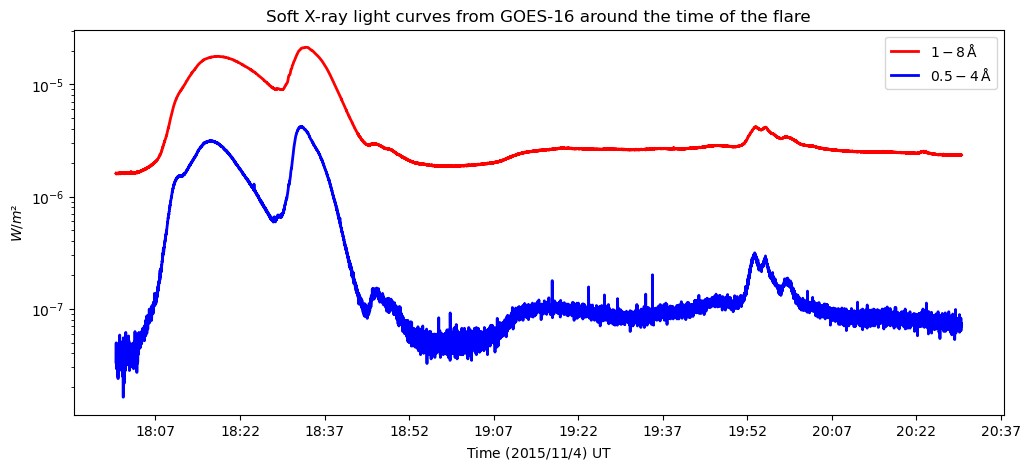

In [638]:
plt.figure(figsize=(12,5))
plt.plot(goes_flare.index, goes_flare['xrsb'], 'r-', label=r'$1-8\,\rm\AA$', linewidth=2)
plt.plot(goes_flare.index, goes_flare['xrsa'], 'b-', label=r'$0.5-4\,\rm\AA$', linewidth=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
plt.yscale('log')
plt.ylabel(r'$W/m²$')
plt.xlabel(r'Time $(2015/11/4)$ UT')
plt.title('Soft X-ray light curves from GOES-16 around the time of the flare')
plt.legend()
plt.show()

#### For our QPP analysis, we'll use XRSB (1-8 Å) because it is what defines the M-class rating.

#### Also, it has better signal-to-noise ratio, broader energy range (which overlaps with STIX

#### lower energy bands). 

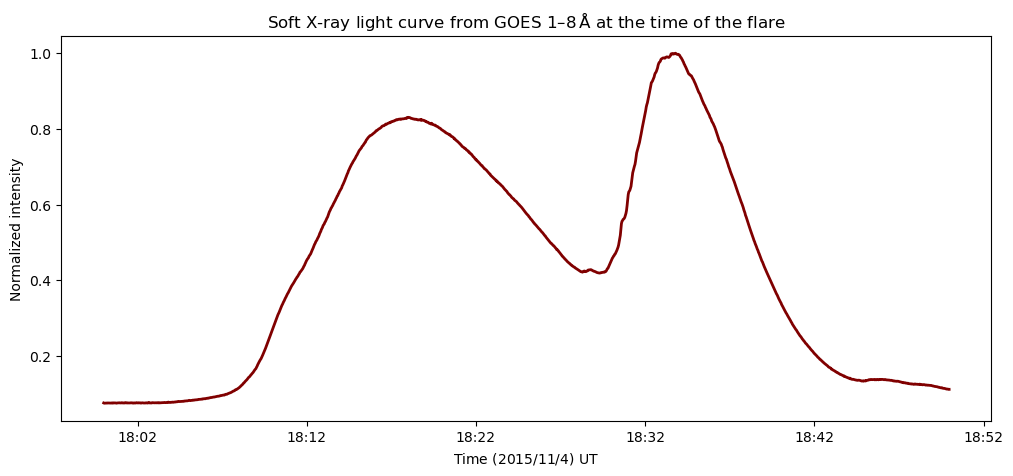

In [639]:
goes_df = goes[0].to_dataframe().truncate("2024-10-15 18:00:00","2024-10-15 18:50:00")
goes_df = goes_df.resample('2s').mean()
intensity = goes_df['xrsb']
norm_intensity = intensity / intensity.max()

plt.figure(figsize=(12,5))
plt.plot(norm_intensity.index, norm_intensity, c='maroon', lw=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
plt.xlabel(r'Time $(2015/11/4)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Soft X-ray light curve from GOES $1–8\,\rm\AA$ at the time of the flare')
plt.show()

#### Because we want to examine Neupert effect later, we'll calculate SXR derivative.

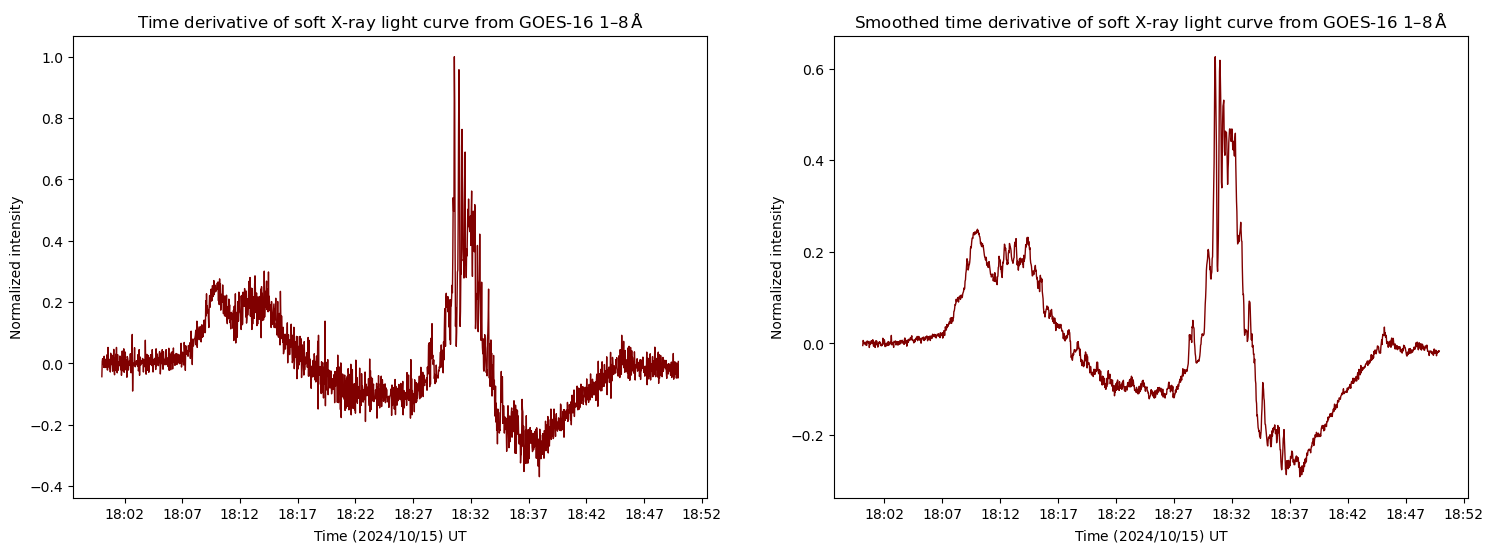

In [640]:
dt = norm_intensity.index.to_series().diff().dt.total_seconds()
dint_dt = norm_intensity.diff()/dt
dint_dt = dint_dt.dropna()
dint_dt_norm = dint_dt / dint_dt.max()

smooth_window = int(12 / 2)  # smoothing
smooth_goes_derv = dint_dt_norm.rolling(window=smooth_window, center=True).mean().dropna()

plt.figure(figsize=(18,6))
plt.subplot(121)
plt.plot(dint_dt_norm, c='maroon', lw=1)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Time derivative of soft X-ray light curve from GOES-16 $1–8\,\rm\AA$')

plt.subplot(122)
plt.plot(smooth_goes_derv, c='maroon', lw=1)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Smoothed time derivative of soft X-ray light curve from GOES-16 $1–8\,\rm\AA$')
plt.show()

### $\color{red}{\text{3. Hard X-ray (HXR) light curve from Fermi GBM}} $

---

#### We use HXR light curve observed by the Fermi GBM ($25–50\,\rm keV$). We also show Neupert effect (with the 

#### derivative of SXR light curve from above) which is supposed to be correct.

In [641]:
res = Fido.search(a.Time("2024-10-15 18:00", "2024-10-15 19:00"), a.Instrument('GBM'), a.Source('FERMI'), a.Detector('N5'), a.Physobs('flux'))

In [642]:
files = Fido.fetch(res)
gbm = TimeSeries(files, concatenate=True)

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

In [643]:
print(gbm.columns)

gbm_df = gbm.to_dataframe()
print(f"Original GBM time range: {gbm_df.index[0]} to {gbm_df.index[-1]}")
print(f"Original time resolution: {(gbm_df.index[1] - gbm_df.index[0]).total_seconds():.3f} seconds")

['4-15 keV', '15-25 keV', '25-50 keV', '50-100 keV', '100-300 keV', '300-800 keV', '800-2000 keV']
Original GBM time range: 2024-10-14 23:59:52.619436145 to 2024-10-15 23:59:59.955803990
Original time resolution: 4.096 seconds


In [644]:
gbm_df = gbm.to_dataframe()
gbm_df = gbm_df.truncate("2024-10-15 18:00:00","2024-10-15 18:50:00")
gbm_r = gbm_df.resample('1600ms').mean().dropna() # resampling

dt = gbm_r.index.to_series().diff().dt.total_seconds().dropna()
print("Check: new median delta t(s)= ", dt.median())

# norm_gbm = (gbm_r - gbm_r.min()) / (gbm_r.max() - gbm_r.min())
# smooth_window = int(5 / 1.6)  # smoothing
# smooth_gbm = norm_gbm.rolling(window=smooth_window, center=True).mean().dropna()
# with open('fermi_gbm.pkl', 'wb') as fout:
#     pickle.dump(smooth_gbm, fout)

Check: new median delta t(s)=  1.6


---

#### This plot might look ugly, but we plot few energy bands anyways!

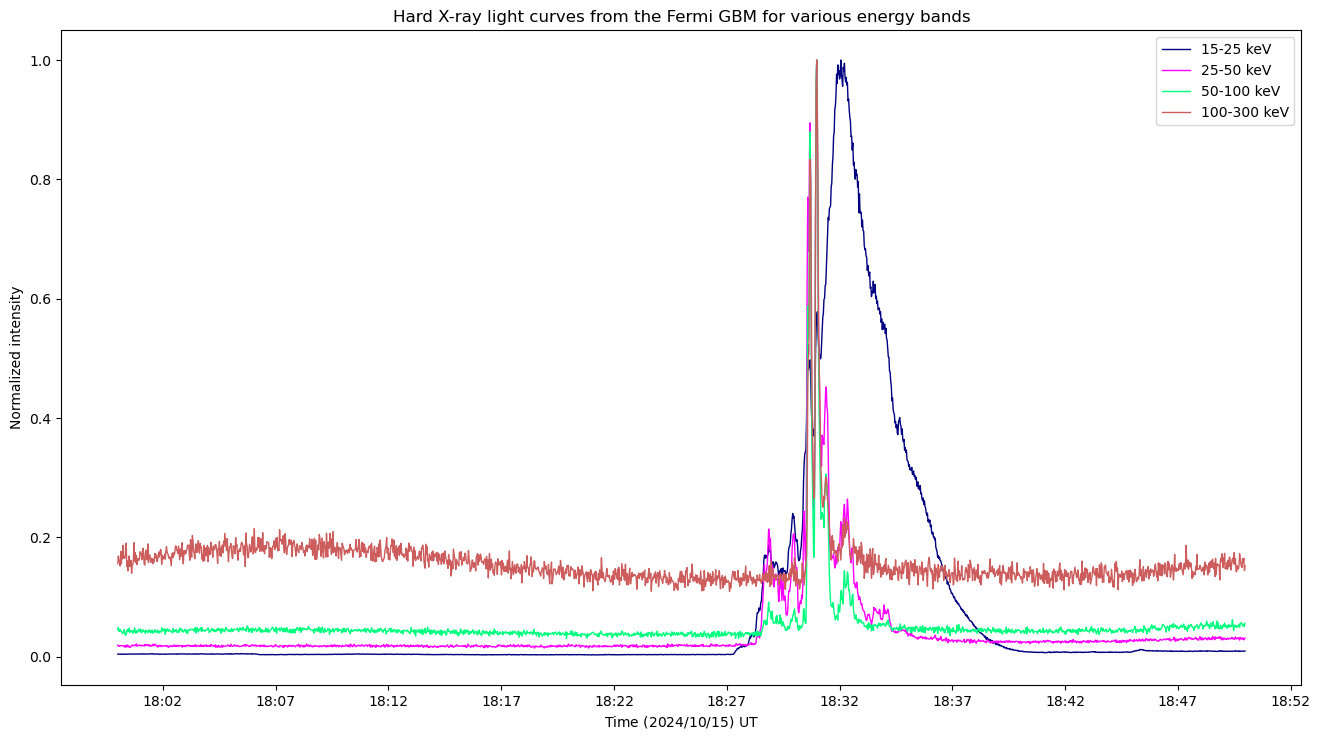

In [645]:
energy_bands = ['15-25 keV', '25-50 keV', '50-100 keV', '100-300 keV']

plt.figure(figsize=(16,8.5))
colors = ['navy', 'magenta', 'springgreen', 'indianred']

for i, band in enumerate(energy_bands):
    gbm_band = gbm_r[band]
    norm_gbm_band = gbm_band / gbm_band.max()
    plt.plot(norm_gbm_band.index, norm_gbm_band, color=colors[i], label=f'{band}', linewidth=1)

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Hard X-ray light curves from the Fermi GBM for various energy bands')
plt.legend()
plt.show()

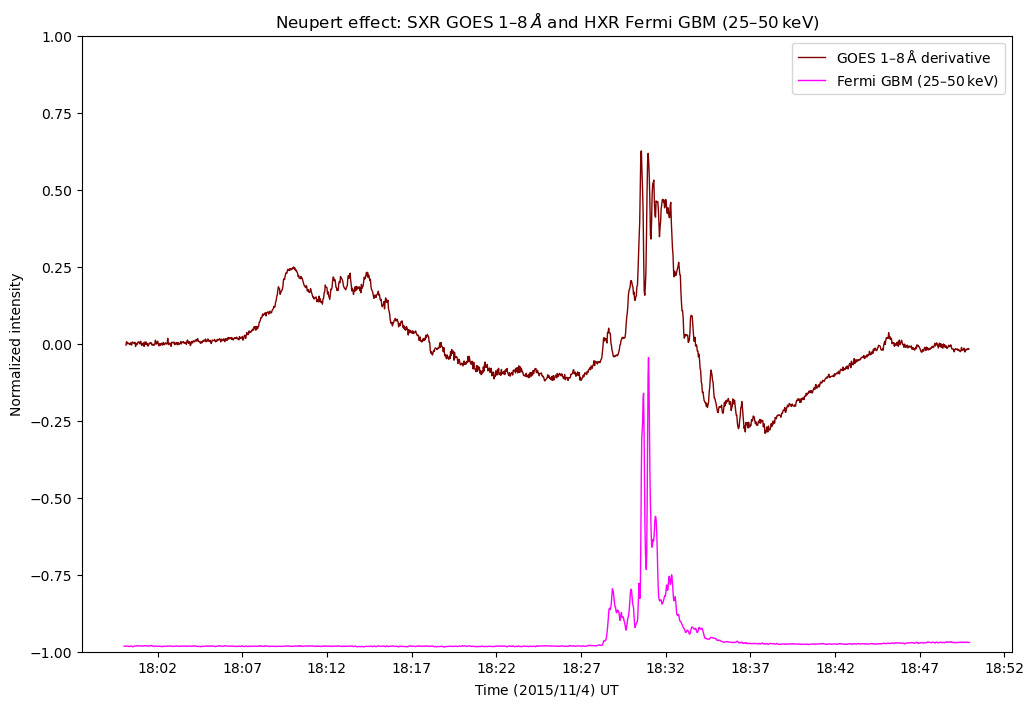

In [646]:
offset = 1
gbm = gbm_r['25-50 keV']
norm_gbm = gbm/gbm.max()

smooth_window = int(5 / 1.6)  # smoothing
smooth_gbm = norm_gbm.rolling(window=smooth_window, center=True).mean().dropna()
smooth_gbm = smooth_gbm - offset

plt.figure(figsize=(12,8))
plt.plot(smooth_goes_derv.index, smooth_goes_derv, c='maroon', lw=1, label=r'GOES $1–8\,\rm\AA$ derivative')
plt.plot(smooth_gbm.index, smooth_gbm, c='magenta', lw=1, label=r'Fermi GBM ($25–50\,\rm keV$)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))

plt.ylim(-1, 1)
plt.xlabel(r'Time $(2015/11/4)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'Neupert effect: SXR GOES $1–8\,\AA$ and HXR Fermi GBM ($25–50\,\rm keV$)')
plt.legend()
plt.show()

### $\color{red}{\text{4. EUI/HRIEUV intensity profiles}} $

---

#### Here, we try to extract EUI/HRIEUV lightcurves from various kernels.

In [33]:
res = Fido.search(a.Time("2024-10-15 18:20", "2024-10-15 18:50"), 
                  a.Instrument.eui, a.soar.Product('eui-hrieuv174-image-short'),
                  a.Level(2))

In [648]:
p = '/home/zorzeus/sunpy/data'
files_eui = sorted(glob.glob(f'{p}/solo_L2_eui-hrieuv174*.fits'))
print(len(files_eui))

676


In [649]:
m = Map(files_eui[200]) # we check some properties

print(f"Image dimensions: {m.data.shape}")
print(f"Instrument: {m.instrument}")
print(f"Wavelength: {m.wavelength}")
print(f"Exposure time: {m.exposure_time}")
print(f"Pixel scale: {m.scale}")

Image dimensions: (2048, 2048)
Instrument: EUI
Wavelength: 174.0 Angstrom
Exposure time: 0.04 s
Pixel scale: SpatialPair(axis1=<Quantity 0.492 arcsec / pix>, axis2=<Quantity 0.492 arcsec / pix>)


In [650]:
max_intensities = []
times = []

for file in files_eui:
    m = Map(file)
    max_intensities.append(np.max(m.data))
    times.append(m.date)

times_dt = [t.datetime for t in times]

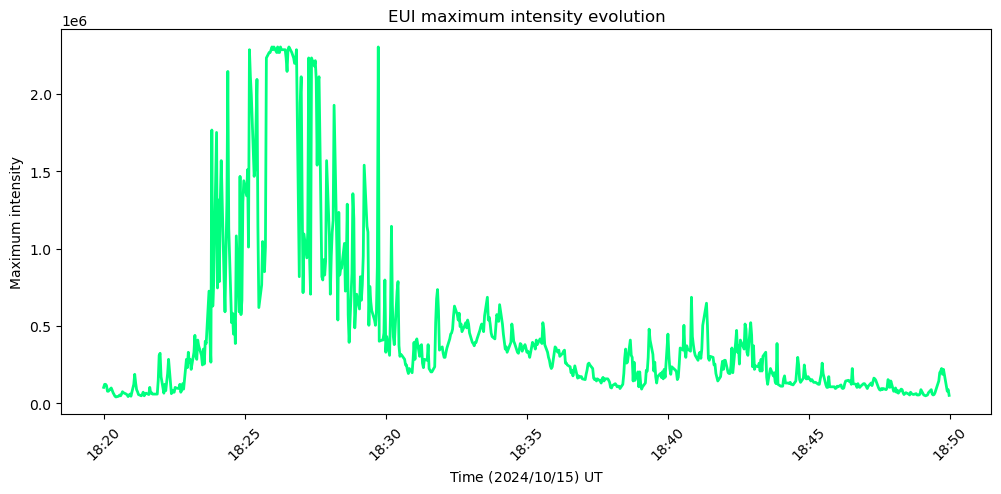

Peak intensity at: 2024-10-15T18:25:58.245
Peak intensity value: 2302311.25
File index: 135


In [653]:
plt.figure(figsize=(12, 5))
plt.plot(times_dt, max_intensities, color='springgreen', linewidth=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Maximum intensity')
plt.title('EUI maximum intensity evolution')
plt.xticks(rotation=45)
plt.show()

peak_idx = np.argmax(max_intensities) # we find peak time
peak_time = times[peak_idx]
print(f"Peak intensity at: {peak_time}")
print(f"Peak intensity value: {max_intensities[peak_idx]}")
print(f"File index: {peak_idx}")

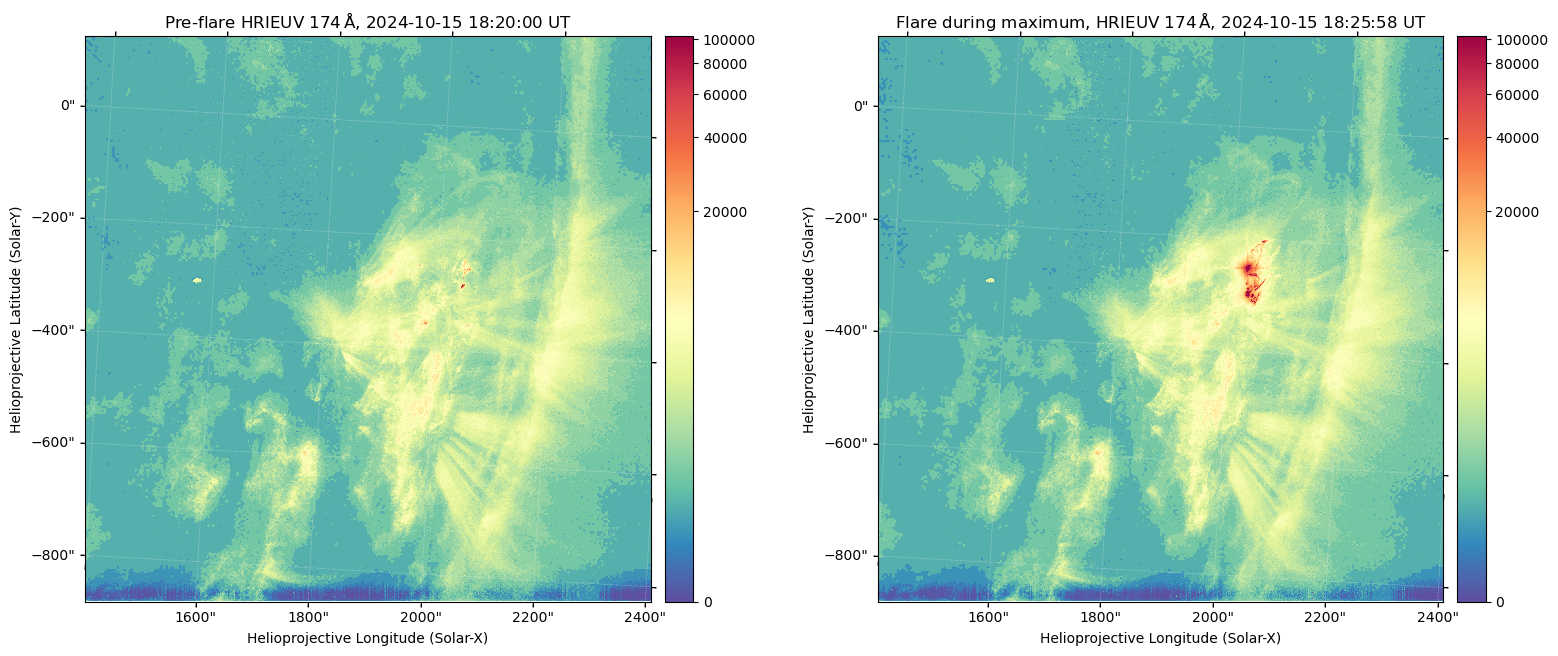

In [656]:
m0 = Map(files_eui[0])
m1 = Map(files_eui[135])

fig = plt.figure(figsize=(16, 6.5))

ax1 = fig.add_subplot(1,2,1, projection=m0)
m0.plot(axes=ax1, cmap='Spectral_r', vmax=np.max(m0))
cbar1 = plt.colorbar(ax1.images[0], ax=ax1, orientation='vertical', pad=0.02)
ax1.set_title(rf'Pre-flare HRIEUV $174\,\rm\AA$, {m0.date.strftime("%Y-%m-%d %H:%M:%S")} UT')

ax2 = fig.add_subplot(1,2,2, projection=m1)
m1.plot(axes=ax2, cmap='Spectral_r', vmax=np.max(m0)) 
cbar2 = plt.colorbar(ax2.images[0], ax=ax2, orientation='vertical', pad=0.02)
ax2.set_title(rf'Flare during maximum, HRIEUV $174\,\rm\AA$, {m1.date.strftime("%Y-%m-%d %H:%M:%S")} UT')
plt.tight_layout()
plt.show()

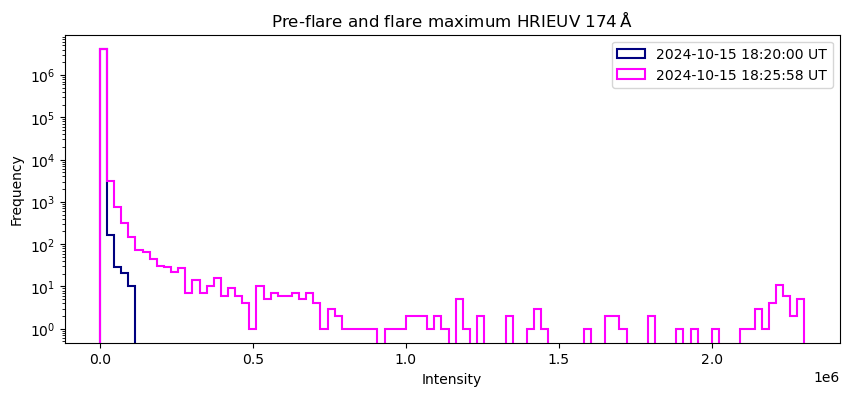

In [657]:
num_bins = 100
bins = np.linspace(m1.min(), m1.max(), num_bins)

hist0 = np.histogram(m0.data, bins=bins)
hist1 = np.histogram(m1.data, bins=bins)

plt.figure(figsize=(10,4))
plt.hist(m0.data.ravel(), bins=bins, color='navy', lw=1.5, label=rf'{m0.date.strftime("%Y-%m-%d %H:%M:%S")} UT', 
histtype='step', range=(np.min(m1), np.max(m1)))
plt.hist(m1.data.ravel(), bins=bins, color='magenta', lw=1.5, label=rf'{m1.date.strftime("%Y-%m-%d %H:%M:%S")} UT', 
         histtype='step',range=(np.min(m1), np.max(m1)))
plt.xlabel('Intensity')
plt.ylabel('Frequency')
plt.yscale('log')
plt.title(r'Pre-flare and flare maximum HRIEUV $174\,\rm\AA$')
plt.legend()
plt.show()

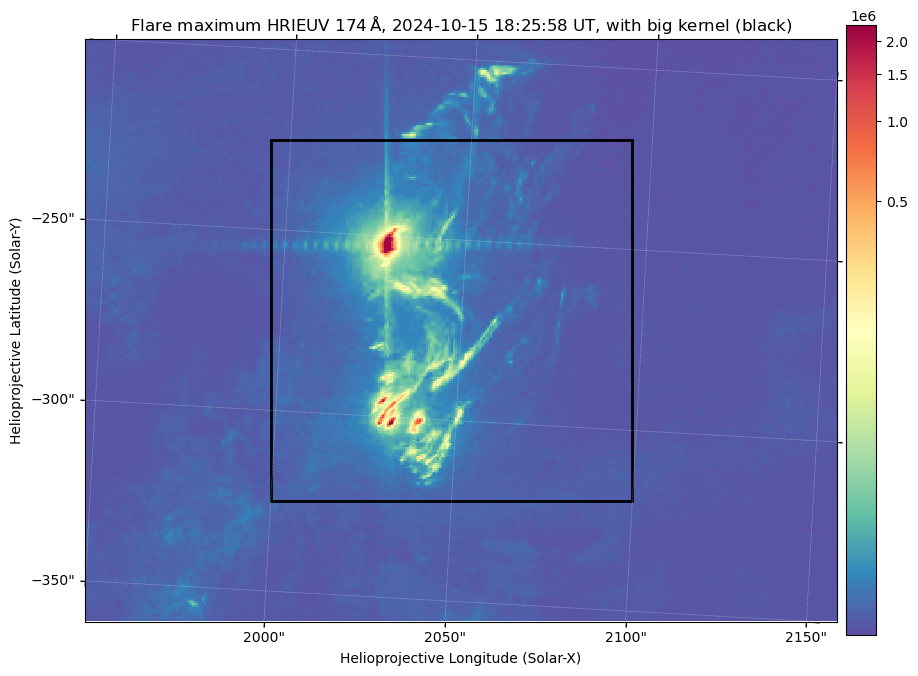

In [658]:
bl1= SkyCoord(1950*u.arcsec, -350*u.arcsec, frame=m1.coordinate_frame)
tr1 = SkyCoord(2150*u.arcsec, -200*u.arcsec, frame=m1.coordinate_frame)
sm1 = m1.submap(bottom_left=bl1, top_right=tr1)
levels = [25, 50, 75] * u.percent

fig = plt.figure(figsize=(10,7))
ax1 = plt.subplot(111, projection=sm1)  
sm1.plot(axes=ax1 ,cmap='Spectral_r')
cbar = plt.colorbar(ax1.images[0], ax=ax1, orientation='vertical', pad=0.01)

kernels = [SkyCoord(2000*u.arcsec, -325*u.arcsec, frame=sm1.coordinate_frame)]
           #SkyCoord(2100*u.arcsec, -200*u.arcsec, frame=sm1.coordinate_frame)]

cdelt_deg = abs(sm1.wcs.wcs.cdelt[0]) # deg / pixel
arcsec_per_pix = cdelt_deg * 3600 # arcsec / pixel
size_pix = 100 / arcsec_per_pix             

for corner in kernels:
    xpix, ypix = sm1.world_to_pixel(corner)
    rect = Rectangle((xpix.value, ypix.value),
                         size_pix, size_pix,
                         edgecolor='black', facecolor='none', lw=2,
                         transform=ax1.transData)
    ax1.add_patch(rect)

plt.title(rf'Flare maximum HRIEUV $174\,\rm\AA$, {m1.date.strftime("%Y-%m-%d %H:%M:%S")} UT, with big kernel (black)') 
plt.tight_layout()
plt.show()

#### We notice that the grid isn't perfectly rectangular because we're working in helioprojective coordinates

#### on a spherical surface, and Solar Orbiter has a different viewing angle than Earth-based observations.

#### However, this shouldn't be problematic for QPP analysis, because we don't perform precise astrometry

#### and slight misalignments won't affect our intensity measurements significantly. 

---

#### We extract light curve from big kernel (black-colored rectangle on previous plot). 

In [163]:
bl1= SkyCoord(2000*u.arcsec, -325*u.arcsec, frame=m1.coordinate_frame)
tr1 = SkyCoord(2100*u.arcsec, -225*u.arcsec, frame=m1.coordinate_frame)
sm1 = m1.submap(bottom_left=bl1, top_right=tr1)

times1, flux1 = [], []

for fn in files_eui:
    m = Map(fn)
    times1.append(pd.Timestamp(m.date.iso))
    sub = m.submap(bottom_left=bl1, top_right=tr1)
    data = sub.data
    if np.isnan(data).all():y
        flux1.append(np.nan)
    else:
        flux1.append(np.nanmean(data))
    del m 

lc1= pd.Series(flux1, index=pd.DatetimeIndex(times1))
lc1_norm = lc1  / lc1.max()
lc1_norm.to_pickle("eui_big_kernel.pkl")

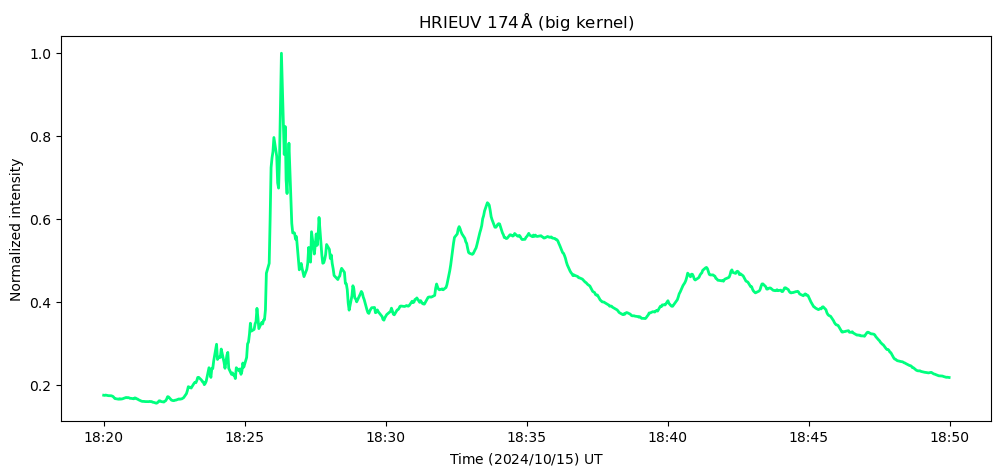

In [343]:
lc_big_kernel = pd.read_pickle('eui_big_kernel.pkl')

plt.figure(figsize=(12,5))
plt.plot(lc_big_kernel.index, lc_big_kernel, color='springgreen', lw=2)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
plt.xlabel(r'Time $(2024/10/15)$ UT')
plt.ylabel('Normalized intensity')
plt.title(r'HRIEUV $174\,\rm\AA$ (big kernel)')
plt.show()

#### This light curve is not time-corrected. We continue by making multiple smaller kernels.

#### We plan to extract light curves from all of those kernels and examine them.

In [10]:
kernel_size = 30 # arcsec
step_size = 15 # arcsec (50% overlap)
lon_start, lon_end = 1970, 2130 # arcsec
lat_start, lat_end = -340, -180 # arcsec

longitude_range = np.arange(lon_start, lon_end - kernel_size, step_size)
latitude_range = np.arange(lat_start, lat_end - kernel_size, step_size)

print(f"Longitude positions: {len(longitude_range)}")
print(f"Latitude positions: {len(latitude_range)}")
print(f"Total kernels: {len(longitude_range) * len(latitude_range)}")

kernel_positions = []
kernel_names = []

for i, lon in enumerate(longitude_range):
    for j, lat in enumerate(latitude_range):
        bl_corner = SkyCoord(lon*u.arcsec, lat*u.arcsec, frame=m1.coordinate_frame)
        tr_corner = SkyCoord((lon + kernel_size)*u.arcsec, (lat + kernel_size)*u.arcsec, frame=m1.coordinate_frame)
        
        kernel_positions.append((bl_corner, tr_corner))
        kernel_names.append(f"kernel_{i:02d}_{j:02d}")

print(f"Created {len(kernel_positions)} overlapping kernels")

Longitude positions: 9
Latitude positions: 9
Total kernels: 81
Created 81 overlapping kernels


In [55]:
def extract_lightcurves(files_eui, kernel_positions, kernel_names, output_dir="eui_kernel_lightcurves"):

    os.makedirs(output_dir, exist_ok=True)
    print(f"Extracting {len(kernel_names)} kernels...")
    print(f"Output directory: {output_dir}")
    
    for idx, ((bl_corner, tr_corner), name) in enumerate(zip(kernel_positions, kernel_names)):
        print(f"Processing ({idx+1}/{len(kernel_names)})...")
        times = []
        flux = []
        for file_idx, fn in enumerate(files_eui):
            m = Map(fn)
            times.append(pd.Timestamp(m.date.iso))
            sub = m.submap(bottom_left=bl_corner, top_right=tr_corner)
            data = sub.data
            if np.isnan(data).all():
                flux.append(np.nan)
            else:
                flux.append(np.nanmean(data))
            del m
            if (file_idx + 1) % 100 == 0:
                print(f"Processed {file_idx+1}/{len(files_eui)} images!")
        
        lc = pd.Series(flux, index=pd.DatetimeIndex(times))
        lc_norm = lc / lc.max()
        filename = os.path.join(output_dir, f"{name}.pkl")
        lc_norm.to_pickle(filename)
        print(f"Saved {name}.pkl")
    
    print("="*60)
    print(f"Successfully saved {len(kernel_names)} lightcurves to {output_dir}/")

#### The light curve extraction and processing procedures turned out to be quite time-consuming when 

#### performed on a local machine. In order to speed up the analysis and handle larger datasets more

#### efficiently, we transferred the workflow to a remote server with greater computational capacity.

#### Alternatives to that would be to utilize numba's features or fully vectorized approach.

In [221]:
lightcurve_dir = "eui_lightcurves"
lc_files = sorted(glob.glob(f"{lightcurve_dir}/kernel_*.pkl"))

eui_lcs = {}
for file in lc_files:
    kernel_name = os.path.basename(file).replace('.pkl', '')
    eui_lcs[kernel_name] = pd.read_pickle(file)

#### We create short animation that shows every light curve we extracted!

In [251]:
def create_lightcurve_movie(output_name='eui_lightcurves.gif', 
                           fps=2, interval=500, show_legend=True, writer='pillow'):
    
    print("="*60)
    print("Creating animation")
    print("="*60)
    print(f"Found {len(eui_lcs)} kernel lightcurves!")
    
    if not eui_lcs:
        print("Error: No lightcurves found!")
        return
    
    kernel_names = list(eui_lcs.keys())
    total_frames = len(kernel_names)
    
    print(f"Animation will have {total_frames} frames (one per kernel)")
    print(f"FPS: {fps}, Interval: {interval}ms")
    print("-"*60)
    
    try:
        print("Setting up figure...")
        fig, ax = plt.subplots(figsize=(16, 8.5))
        
        def animate(frame):
            if frame % max(1, total_frames // 10) == 0:
                progress = (frame / total_frames) * 100
                print(f"Rendering frame {frame}/{total_frames} ({progress:.1f}%)")
            ax.clear()

            current_kernel = kernel_names[frame]
            lc = eui_lcs[current_kernel]
            parts = current_kernel.split('_')
            i, j = int(parts[1]), int(parts[2])
            lon_start, lat_start = 1970, -340
            step_size = 15
            kernel_size = 30
            
            lon = lon_start + i * step_size
            lat = lat_start + j * step_size
            lc_normalized = (lc - lc.min()) / (lc.max() - lc.min())
            
            ax.plot(lc.index, lc_normalized, color='springgreen', linewidth=2)
            ax.set_xlabel('Time (2024/10/15) UT')
            ax.set_ylabel('Normalized intensity')
            ax.set_title(f'HRIEUV extracted from kernel [longitude ({lon}", {lon+kernel_size}"), latitude ({lat}", {lat+kernel_size}")]')
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
        
        print("Starting animation creation...")
        ani = animation.FuncAnimation(fig, animate, frames=total_frames, interval=interval, repeat=True)
        print("Saving animation file...")
        
        if writer == 'html':
            ani.save(output_name, writer='html', fps=fps)
        elif writer == 'pillow':
            ani.save(output_name, writer='pillow', fps=fps)
        else:
            print(f"Error: Unknown writer '{writer}'. Use 'html' or 'pillow'")
            return
        
        plt.close(fig)
        
        print("Animation saved successfully!")
        if os.path.exists(output_name):
            file_size = os.path.getsize(output_name) / (1024*1024)
            print(f"File size: {file_size:.2f} MB")

    except Exception as e:
        print(f"Error creating animation: {e}")
        return

In [252]:
create_lightcurve_movie()

2025-07-31 21:54:52 - matplotlib.animation - INFO: Animation.save using <class 'matplotlib.animation.PillowWriter'>


Creating animation
Found 81 kernel lightcurves!
Animation will have 81 frames (one per kernel)
FPS: 2, Interval: 500ms
------------------------------------------------------------
Setting up figure...
Starting animation creation...
Saving animation file...
Rendering frame 0/81 (0.0%)
Rendering frame 0/81 (0.0%)
Rendering frame 8/81 (9.9%)
Rendering frame 16/81 (19.8%)
Rendering frame 24/81 (29.6%)
Rendering frame 32/81 (39.5%)
Rendering frame 40/81 (49.4%)
Rendering frame 48/81 (59.3%)
Rendering frame 56/81 (69.1%)
Rendering frame 64/81 (79.0%)
Rendering frame 72/81 (88.9%)
Rendering frame 80/81 (98.8%)
Animation saved successfully!
File size: 2.56 MB


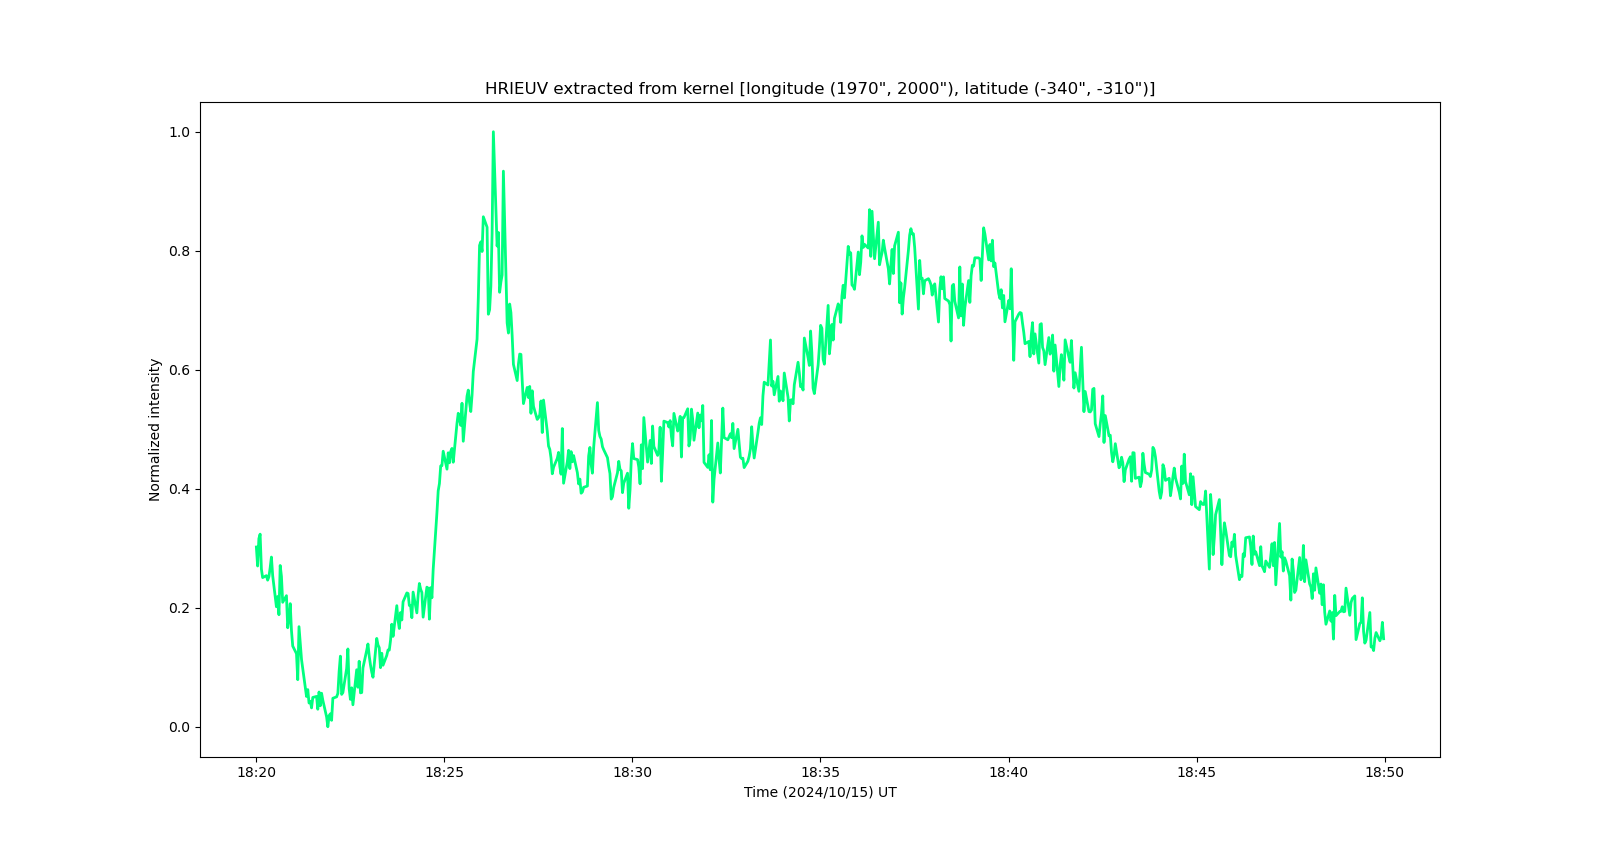

### $\color{red}{\text{6. Time correction and HRIEUV kernel selection.}} $

---

#### Solar Orbiter is closer to the Sun, and there is a time shift between Earth (i.e. GOES/Fermi) and STIX/EUI of 

#### around 281 seconds. Also, since we generated EUV light curves from multiple kernels, we need to decide on

#### which one is best to for period determination.

In [512]:
stix_lcs_corrected = {} # time correction
for band_name, lc in stix_lcs.items():
    corrected_times = lc.index + pd.Timedelta(seconds=281)
    stix_lcs_corrected[band_name] = pd.Series(lc.values, index=corrected_times, name=f"{band_name} (corrected)")
stix_lcs_corrected = {band: lc/lc.max() for band, lc in stix_lcs_corrected.items()} # normalization

eui_lcs_corrected = {} # time correction
for kernel, lc in eui_lcs.items():
    corrected_times = lc.index + pd.Timedelta(seconds=281)
    eui_lcs_corrected[kernel] = pd.Series(lc.values, index=corrected_times, name=f"{kernel} (corrected)")
eui_lcs_corrected = {kernel: lc/lc.max() for kernel, lc in eui_lcs_corrected.items()} # normalization

lc_big_kernel = pd.read_pickle('eui_big_kernel.pkl')
lc_big_kernel = lc_big_kernel.shift(freq='281S')

# we rename some of our light curves
goes_lc = smooth_goes_derv
fermi_lc = norm_gbm

In [522]:
start_time = pd.Timestamp('2024-10-15 18:24:00')
end_time = pd.Timestamp('2024-10-15 18:44:00')

stix_lcs_t = {}
for band, lc in stix_lcs_corrected.items():
    stix_lcs_t[band] = lc[(lc.index >= start_time) & (lc.index <= end_time)]

eui_lcs_t = {}
for kernel, lc in eui_lcs_corrected.items():
    eui_lcs_t[kernel] = lc[(lc.index >= start_time) & (lc.index <= end_time)]

smooth_window = int(6 / 2)  # smoothing
for kernel, lc in eui_lcs_t.items():
    eui_lcs_t[kernel] = lc.rolling(window=smooth_window, center=True).mean().dropna()

lc_big_kernel_t = lc_big_kernel[(lc_big_kernel.index >= start_time) & (lc_big_kernel.index <= end_time)]

goes_lc_t = goes_lc[(goes_lc.index >= start_time) & (goes_lc.index <= end_time)]
fermi_lc_t = fermi_lc[(fermi_lc.index >= start_time) & (fermi_lc.index <= end_time)]

print("Time ranges after trimming:")
print(f"STIX: {stix_lcs_t['25-50 keV'].index[0]} to {stix_lcs_t['25-50 keV'].index[-1]}")
print(f"EUI: {list(eui_lcs_t.values())[0].index[0]} to {list(eui_lcs_t.values())[0].index[-1]}")
print(f"GOES: {goes_lc_t.index[0]} to {goes_lc_t.index[-1]}")
print(f"Fermi: {fermi_lc_t.index[0]} to {fermi_lc_t.index[-1]}")

Time ranges after trimming:
STIX: 2024-10-15 18:24:00.665000 to 2024-10-15 18:43:59.915000
EUI: 2024-10-15 18:24:43.244000 to 2024-10-15 18:43:57.278000
GOES: 2024-10-15 18:24:00 to 2024-10-15 18:44:00
Fermi: 2024-10-15 18:24:00 to 2024-10-15 18:44:00


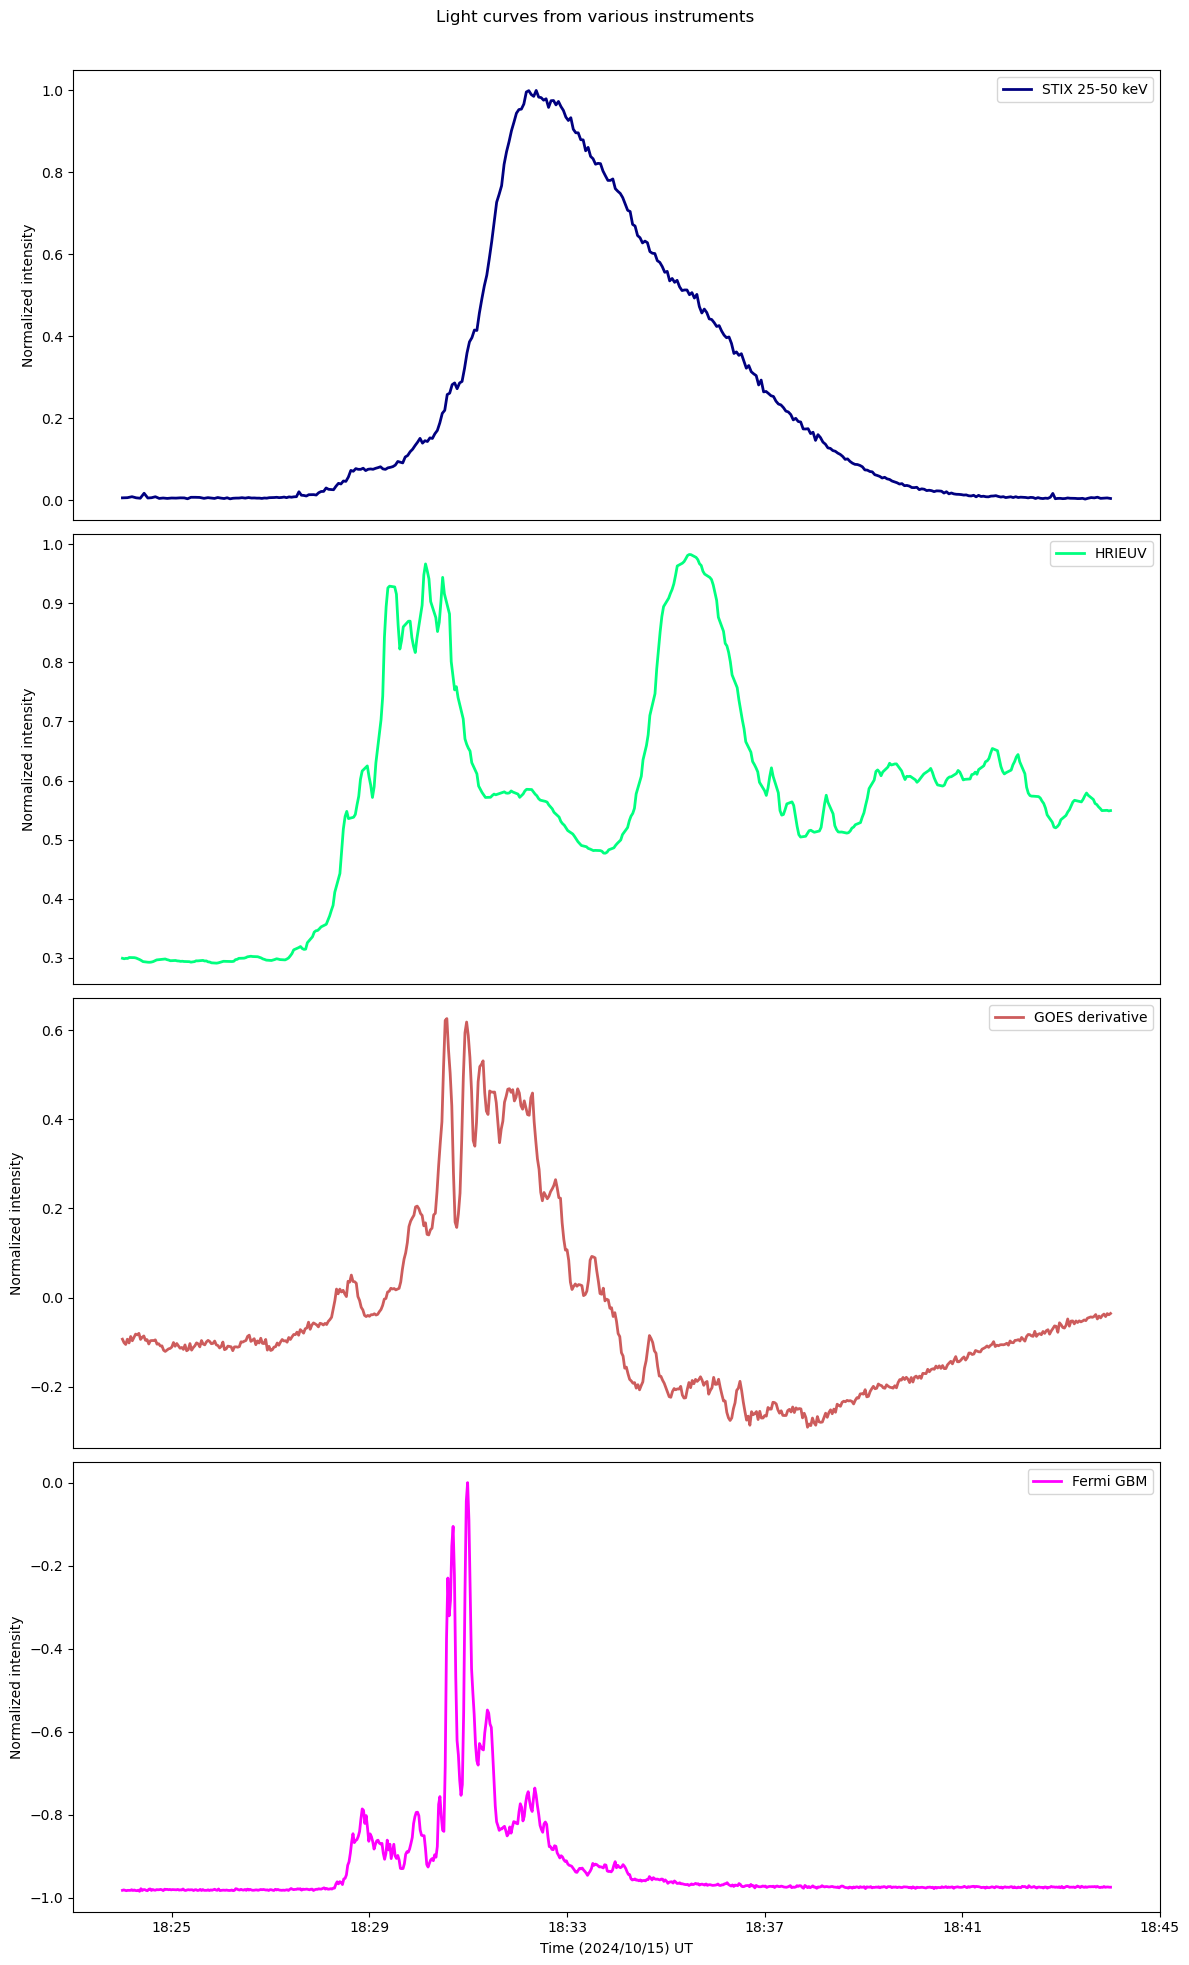

In [660]:
plt.figure(figsize=(12,20))
plt.subplot(411)
plt.plot(stix_lcs_t['25-50 keV'].index, stix_lcs_t['25-50 keV'], color='navy', linewidth=2, label='STIX 25-50 keV')
plt.ylabel('Normalized intensity')
plt.xticks([])
plt.legend()
plt.subplot(412)
plt.plot(eui_lcs_t['kernel_04_07'].index, eui_lcs_t['kernel_04_07'], color='springgreen', linewidth=2, label='HRIEUV')
plt.ylabel('Normalized intensity')
plt.xticks([])
plt.legend()
plt.subplot(413)
plt.plot(goes_lc_t.index, goes_lc_t, color='indianred', linewidth=2, label='GOES derivative')
plt.ylabel('Normalized intensity')
plt.xticks([])
plt.legend()
plt.subplot(414)
plt.plot(fermi_lc_t.index, fermi_lc_t, color='magenta', linewidth=2, label='Fermi GBM')
plt.ylabel('Normalized intensity')
plt.legend()
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.MinuteLocator(interval=4))
plt.xlabel('Time (2024/10/15) UT')
# plt.xticks(rotation=45)
plt.suptitle('Light curves from various instruments')
    
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.savefig('sfi_14.png')
plt.show()

#### We find the EUI kernel with the highest overall correlation with other light curves (other $\lambda$). 

#### Detailed analysis is performed for the best kernel.

In [382]:
def analyze_all_kernels_correlation(stix_lcs, eui_lcs, goes_lc, fermi_lc):
   
   ref_time = stix_lcs['25-50 keV'].index
   stix_interp = stix_lcs['25-50 keV'].reindex(ref_time, method='nearest')
   goes_interp = goes_lc.reindex(ref_time, method='nearest')
   fermi_interp = fermi_lc.reindex(ref_time, method='nearest')
   
   results = []
   
   for kernel_name, eui_lc in eui_lcs.items():
       eui_interp = eui_lc.reindex(ref_time, method='nearest')
       valid_mask = ~(stix_interp.isna() | eui_interp.isna() | goes_interp.isna() | fermi_interp.isna())
       
       if valid_mask.sum() < 10:
           continue
           
       eui_clean = eui_interp[valid_mask]
       stix_clean = stix_interp[valid_mask]
       goes_clean = goes_interp[valid_mask]
       fermi_clean = fermi_interp[valid_mask]
       
       stix_corr = np.corrcoef(eui_clean, stix_clean)[0,1]
       goes_corr = np.corrcoef(eui_clean, goes_clean)[0,1]
       fermi_corr = np.corrcoef(eui_clean, fermi_clean)[0,1]
       
       results.append({
           'Kernel': kernel_name,
           'STIX': stix_corr,
           'GOES': goes_corr,
           'Fermi': fermi_corr,
           'Average': np.mean([stix_corr, goes_corr, fermi_corr])})
   
   results_df = pd.DataFrame(results)
   
   best_overall = results_df.loc[results_df['Average'].idxmax()]
   top_5 = results_df.nlargest(5, 'Average')[['Kernel', 'STIX', 'GOES', 'Fermi', 'Average']]
   
   return results_df, best_overall['Kernel']

def detailed_correlation_for_best_kernel(best_kernel, stix_lcs, eui_lcs, goes_lc, fermi_lc):
   
   ref_time = stix_lcs['25-50 keV'].index
   stix_interp = stix_lcs['25-50 keV'].reindex(ref_time, method='nearest')
   eui_interp = eui_lcs[best_kernel].reindex(ref_time, method='nearest')
   goes_interp = goes_lc.reindex(ref_time, method='nearest')
   fermi_interp = fermi_lc.reindex(ref_time, method='nearest')
   
   valid_mask = ~(stix_interp.isna() | eui_interp.isna() | goes_interp.isna() | fermi_interp.isna())
   
   df = pd.DataFrame({
       'STIX 25-50 keV': stix_interp[valid_mask],
       f'HRIEUI {best_kernel}': eui_interp[valid_mask],
       'GOES derivative': goes_interp[valid_mask],
       'Fermi GBM 25-50 keV': fermi_interp[valid_mask]})
   
   corr_matrix = df.corr()

   for i, row_label in enumerate(['STIX 25-50 keV', f'HRIEUI {best_kernel}', 'GOES derivative', 'Fermi GBM 25-50 keV']):
       short_labels = ['STIX', 'HRIEUI', 'GOES', 'Fermi']
       row_values = []
       for j in range(len(corr_matrix.columns)):
           if i == j:
               row_values.append("1.000")
           else:
               row_values.append(f"{corr_matrix.iloc[i, j]:.3f}")
               
   return corr_matrix

In [400]:
def plot_kernel_correlations_heatmap(results_df):
    
    kernel_coords = []
    for kernel in results_df['Kernel']:
        parts = kernel.split('_')
        i, j = int(parts[1]), int(parts[2])
        lon = 1970 + i * 15
        lat = -340 + j * 15
        kernel_coords.append(f"({lon},{lat})")
    
    plot_data = results_df[['STIX', 'GOES', 'Fermi']].T
    plot_data.columns = kernel_coords
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    im = ax.imshow(plot_data.values, cmap='BrBG', vmin=-1, vmax=1, aspect='auto')
    
    ax.set_xticks(range(len(kernel_coords)))
    ax.set_xticklabels(kernel_coords, rotation=90, fontsize=8)
    ax.set_yticks(range(len(plot_data.index)))
    ax.set_yticklabels(plot_data.index, fontsize=12)
    
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Correlation coefficient', rotation=270, labelpad=15)
    
    for i in range(len(plot_data.index)):
        for j in range(len(kernel_coords)):
            text = ax.text(j, i, f'{plot_data.iloc[i, j]:.2f}',
                          ha="center", va="center", color="white" if abs(plot_data.iloc[i, j]) > 0.5 else "black",
                          fontsize=6, rotation=90)
    
    ax.set_title('EUI kernel correlations with multi-instrument data', fontsize=14, pad=20)
    ax.set_xlabel('EUI kernel position (longitude, latitude)')
    ax.set_ylabel('Instrument')
    
    plt.tight_layout()
    plt.show()
    
    return fig

def plot_best_kernel_correlation_matrix(corr_matrix, best_kernel):
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
    
    sns.heatmap(corr_matrix, mask=mask, annot=True, 
                cmap='inferno', vmin=0, vmax=1,
                square=True, cbar_kws={"shrink": .8}, fmt='.3f', )
    
    ax.set_title(f'Correlation matrix for the best kernel', pad=20)

    labels = [label.replace(best_kernel, '') for label in corr_matrix.columns]
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels, rotation=0)
    plt.tight_layout()
    plt.show()
    
    return fig

def visualize_all_correlations(results_df, best_kernel, corr_matrix):

    fig1 = plot_kernel_correlations_heatmap(results_df)
    fig2 = plot_best_kernel_correlation_matrix(corr_matrix, best_kernel)
    
    return fig1, fig2, fig3    

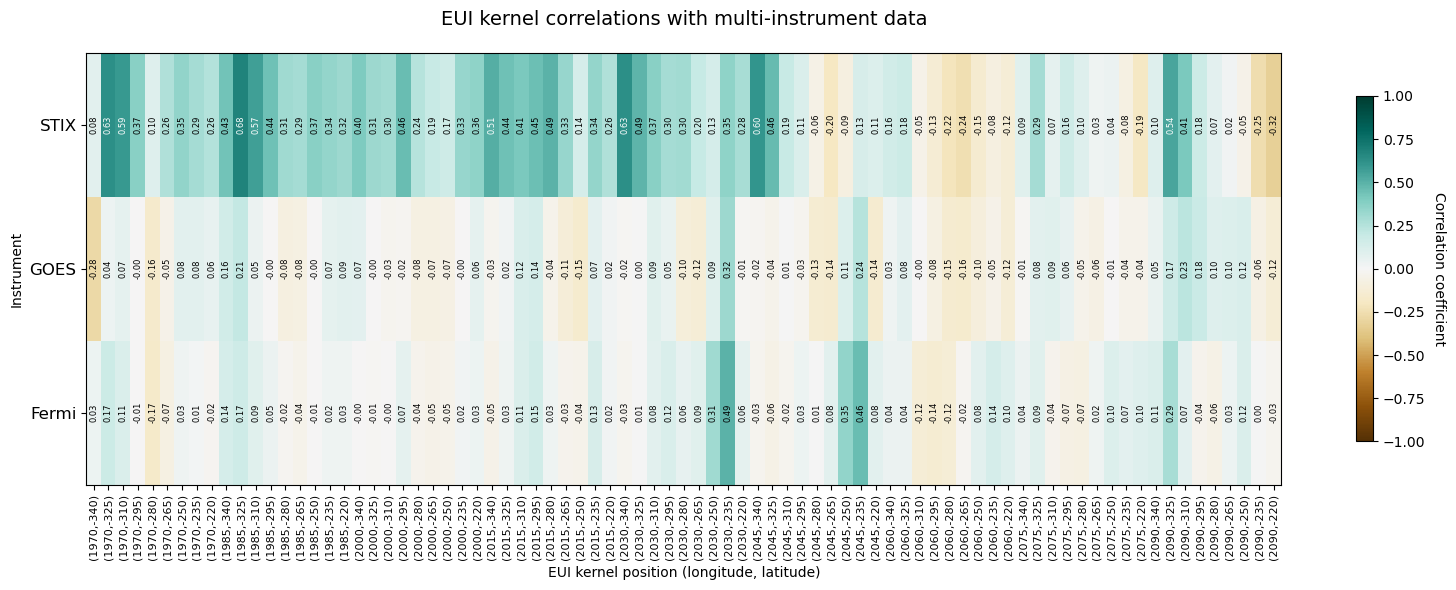

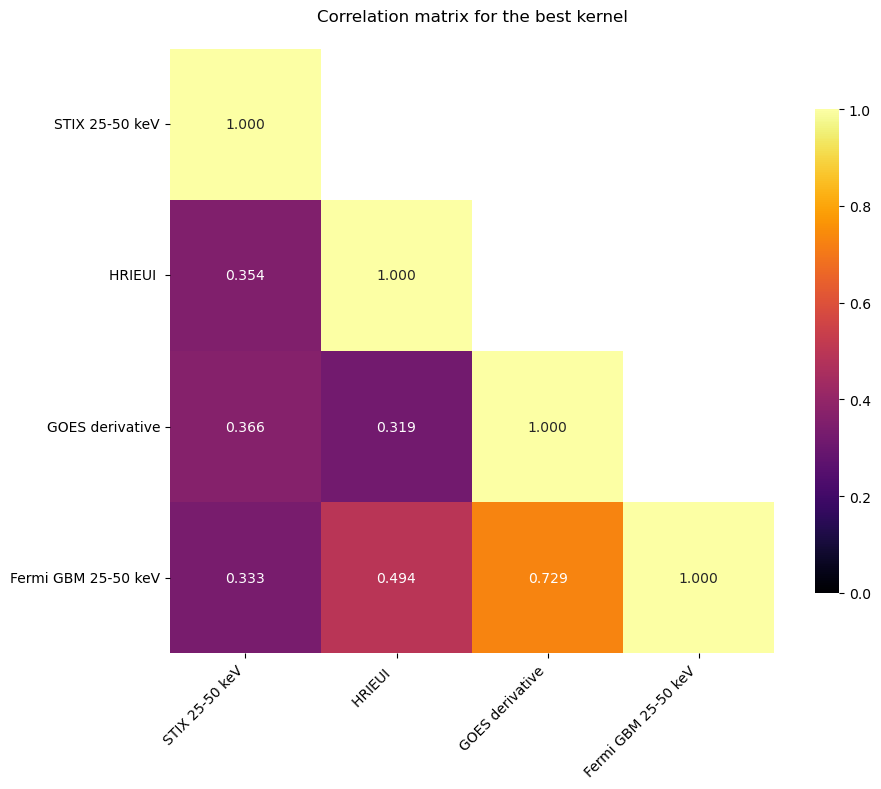

In [401]:
results_df, best_kernel = analyze_all_kernels_correlation(stix_lcs, eui_lcs, goes_lc, fermi_lc)
corr_matrix = detailed_correlation_for_best_kernel(best_kernel, stix_lcs, eui_lcs, goes_lc, fermi_lc)
fig1, fig2, fig3 = visualize_all_correlations(results_df, best_kernel, corr_matrix)

### $\color{red}{\text{7. Determination of the periodicities - WAVELET ANALYSIS}} $

---

#### Here, we perform detailed wavelet analysis of multi-wavelength light curves. Some light curves

#### weren't examined this way, but we deal with them later anyway.

In [612]:
 wavelet_analysis(series: pd.Series,
                           dj: float = 0.25,
                           s0_factor: float = 1.0,
                           pad: int = 2,
                           k0: float = 6.0,
                           samples_between_knots: int = 50,
                           detrend: bool = True,
                           detrend_method: str = "spline",
                           period_min = 30.0, # allows shorter periods
                           period_max = 600.0, # allows longer periods to capture evolution
                           peak_method: str = "ridge",
                           min_ratio: float = 1.0,
                           radio: bool = False):
   
    if isinstance(series, pd.DataFrame):
        if series.shape[1] != 1:
            raise ValueError("Input must be a single column")
        y = series.iloc[:, 0].dropna().sort_index()
    else:
        y = series.dropna().sort_index()
    if not isinstance(y.index, pd.DatetimeIndex):
        raise ValueError("Index must be DateTimeIndex")

    if radio:
        period_min, period_max = 150.0, 300.0
        min_ratio = max(min_ratio, 1.5)

    t = (y.index - y.index[0]).total_seconds().values
    dt = np.median(np.diff(t))
    if dt <= 0:
        raise ValueError("Non-positive time step detected.")
    N = len(y)
    s0 = s0_factor * dt
    J1 = int(np.log2(N * dt / s0) / dj)

    if detrend:
        if detrend_method == "spline":
            knots = np.arange(samples_between_knots, N, samples_between_knots)
            if len(knots) < 2:
                raise ValueError("Insufficient knot points for spline.")
            spline = LSQUnivariateSpline(t, y.values, t[knots], k=3)
            proc = y.values - spline(t)
        elif detrend_method == "savgol":
            window = int(300.0 / dt)
            if window % 2 == 0:
                window += 1
            baseline = savgol_filter(y.values, window_length=window, polyorder=3, mode='interp')
            proc = y.values - baseline
        else:
            raise ValueError("Choose 'spline' or 'savgol' for detrend_method")
        method_label = "Detrended"
    else:
      
        low, high = 1.0/period_max, 1.0/period_min
        fs = 1.0/dt
        nyq = fs/2.0
        w_low, w_high = low/nyq, high/nyq
        if 0 < w_low < w_high < 1:
            b, a = butter(2, [w_low, w_high], btype='bandpass')
            proc = filtfilt(b, a, y.values)
        else:
            proc = y.values.copy()
        method_label = "Bandpass Filtered"

    norm_det = proc / np.max(np.abs(proc))

    wave, period, scale, coi = wavelet(proc, dt, pad=pad, dj=dj,
                                      s0=s0, J1=J1, mother='MORLET', param=k0)
    power = np.abs(wave)**2

    var = np.var(proc, ddof=1)
    lag1 = np.corrcoef(proc[:-1], proc[1:])[0,1]
    sig_local = wave_signif(var, dt, scale, sigtest=0, lag1=lag1, mother='MORLET')
    sig_global = wave_signif(var, dt, scale, sigtest=1, lag1=lag1,
                             dof=np.maximum(1, N-scale), mother='MORLET')

    band = (period>=period_min)&(period<=period_max)
    global_ws = power.mean(axis=1)
    mask = band & (global_ws>sig_local*min_ratio)
    labeled, nregions = nd_label(mask)
    if nregions==0:
        raise ValueError(f"No significant QPP in {period_min}-{period_max}s band")
    best_period = None
    if peak_method=="ridge":
        best_len=-1
        for idx in np.where(mask)[0]:
            length=np.sum(power[idx]>sig_local[idx])
            if length>best_len:
                best_len,length, best_period = length,length,period[idx]
    elif peak_method=="ratio_ridge":
        best_score=-np.inf
        for idx in np.where(mask)[0]:
            ratio=global_ws[idx]/sig_local[idx]
            if ratio<min_ratio: continue
            length=np.sum(power[idx]>sig_local[idx])
            score=ratio*length
            if score>best_score:
                best_score, best_period=score,period[idx]
    else:
        raise ValueError("peak_method must be 'ridge' or 'ratio_ridge'")
    if best_period is None:
        raise ValueError("No period selected")
    sel=(period>=(best_period*(1-dj)))&(period<=(best_period*(1+dj)))&mask
    left=period[sel].min() if sel.any() else best_period
    right=period[sel].max() if sel.any() else best_period
    err_low=best_period-left
    err_high=right-best_period

    fig=plt.figure(figsize=(12,8))
    gs=fig.add_gridspec(2,4,height_ratios=[2,3],width_ratios=[1,1,1,1],
                        hspace=0.1,wspace=0.2)

    ax_ts=fig.add_subplot(gs[0,:3])
    ax_ts.plot(t,norm_det,'k',lw=1)
    ax_ts.set_xlim(t.min(),t.max())
    ax_ts.set_ylim((-1, 1) if detrend else (norm_det.min(), norm_det.max()))
    ax_ts.set_ylabel('Normalized Intensity')
    ax_ts.set_title(r'')
    ax_ts.xaxis.set_visible(False)
 
    ax_box=fig.add_subplot(gs[0,3])
    ax_box.axis('off')
    ax_box.text(0.5,0.5,rf"$P={best_period:.1f}^{{+{err_high:.1f}}}_{{-{err_low:.1f}}}\,s$",
                ha='center',va='center',transform=ax_box.transAxes,
                fontsize=12,bbox=dict(boxstyle='round,pad=0.3',edgecolor='red',
                                     facecolor='indianred',alpha=0.3,linewidth=2))

    ax_wps = fig.add_subplot(gs[1,:3])
    ax_wps.set_facecolor('black')
    T,Pm = np.meshgrid(t,period)
    ax_wps.contourf(T,Pm,power,levels=10,cmap='viridis',extend='both')
    ax_wps.contour(T,Pm,power/sig_local[:,None],levels=[1],colors='orange',linewidths=1)
    ax_wps.plot(t,coi,'w-',lw=1.5)
    ax_wps.fill_between(t,coi,period.max(),facecolor='none',edgecolor='white',alpha=0.3)
    ax_wps.axhline(best_period,color='white',ls='--',lw=1)
    ax_wps.set_xlabel("Time (s)")
    ax_wps.set_ylabel("Period (s)")
    ax_wps.set_yscale('log')
    ymin=period.min()
    ymax=period.max()
    ax_wps.set_ylim(ymin,ymax)
    yticks=[ymin,100,ymax]
    ax_wps.set_yticks(yticks)
    ax_wps.set_xlim(t.min(),t.max())

    ax_gws=fig.add_subplot(gs[1,3],sharey=ax_wps)
    norm_ws=global_ws/np.nanmax(global_ws)
    norm_sig=(sig_local if period_min is not None else sig_global)/np.nanmax(global_ws)
    ax_gws.plot(norm_ws,period,'k')
    ax_gws.plot(norm_sig,period,'k--', label=r'$95\%$ significance')
    ax_gws.axhline(best_period,color='red',ls='--',lw=1)
    ax_gws.set_xscale('log')
    ax_gws.set_xlim(0.001,1)
    ax_gws.set_xlabel("Normalized Power")
    ax_gws.yaxis.set_visible(False)
    ax_gws.set_title('Global spectrum')
    ax_gws.legend()

    return best_period, err_low, err_high, fig

#### Optionally, we can analyze flare phases separately!

In [457]:
def analyze_flare_phases(series, time_ranges, phase_names):
    results = {}
    
    for (start, end), name in zip(time_ranges, phase_names):
        phase_data = series[start:end]

        if 'impulsive' in name.lower():
            period_min, period_max = 30.0, 200.0
            detrend = True
        elif 'peak' in name.lower():
            period_min, period_max = 100.0, 400.0
            detrend = True
        else: # decay
            period_min, period_max = 200.0, 600.0
            detrend = False
        
        try:
            P, err_low, err_high, fig = wavelet_analysis(
                phase_data,
                dj=0.05,
                s0_factor=1.0,
                detrend=detrend,
                detrend_method='savgol',
                period_min=period_min,
                period_max=period_max,
                peak_method='ratio_ridge',
                min_ratio=1.5)
            results[name] = {
                'period': P,
                'err_low': err_low,
                'err_high': err_high,
                'fig': fig}
            print(f"{name}: P = {P:.1f} +{err_high:.1f} -{err_low:.1f} s")
        except ValueError as e:
            print(f"{name}: {e}")
            results[name] = None
    
    return results

time_ranges = [
    ('2024-10-15 18:28:00', '2024-10-15 18:31:00'), # early impulsive
    ('2024-10-15 18:30:00', '2024-10-15 18:34:00'), # peak
    ('2024-10-15 18:33:00', '2024-10-15 18:40:00')  # decay
]
phase_names = ['Early Impulsive', 'Peak Phase', 'Decay Phase']

--- 

#### STIX $25-50\,\rm keV$:

#### wavelet analysis with detrending

---

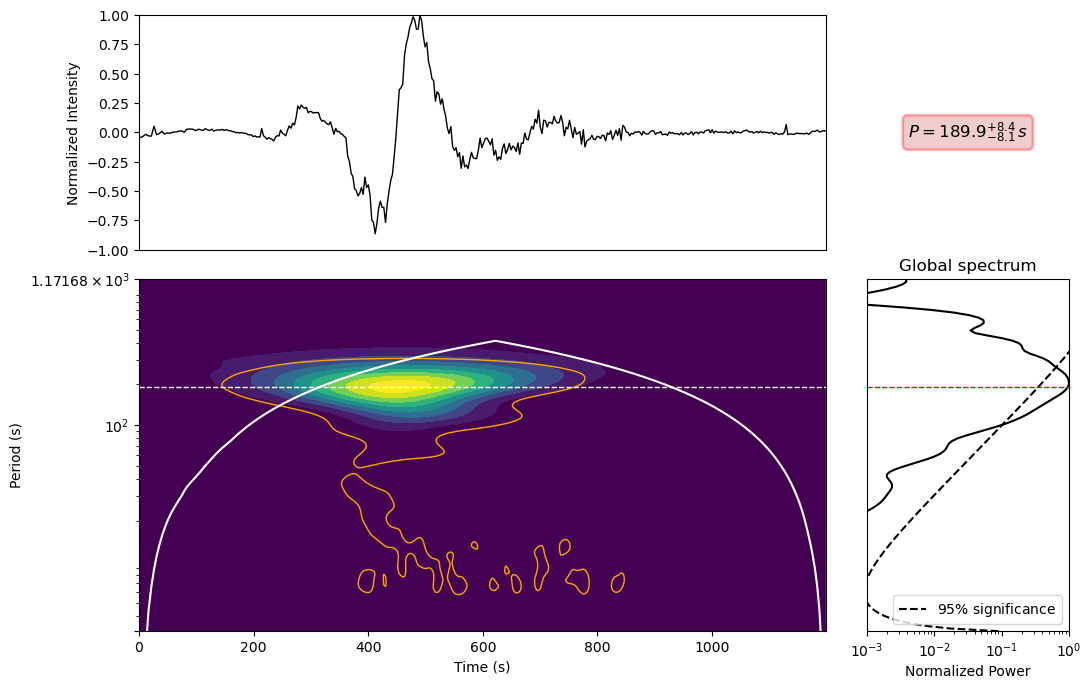

In [615]:
stix_25_50 = stix_lcs_t['25-50 keV']
P0, err_low, err_high, fig = wavelet_analysis(stix_25_50, dj=0.0625,
                                detrend=True, peak_method='ratio_ridge',
                                detrend_method='savgol')
# results = analyze_flare_phases(stix_25_50, time_ranges, phase_names)

--- 

#### HRIEUV $174\,\text{Å}$:

#### - wavelet analysis with detrending

---

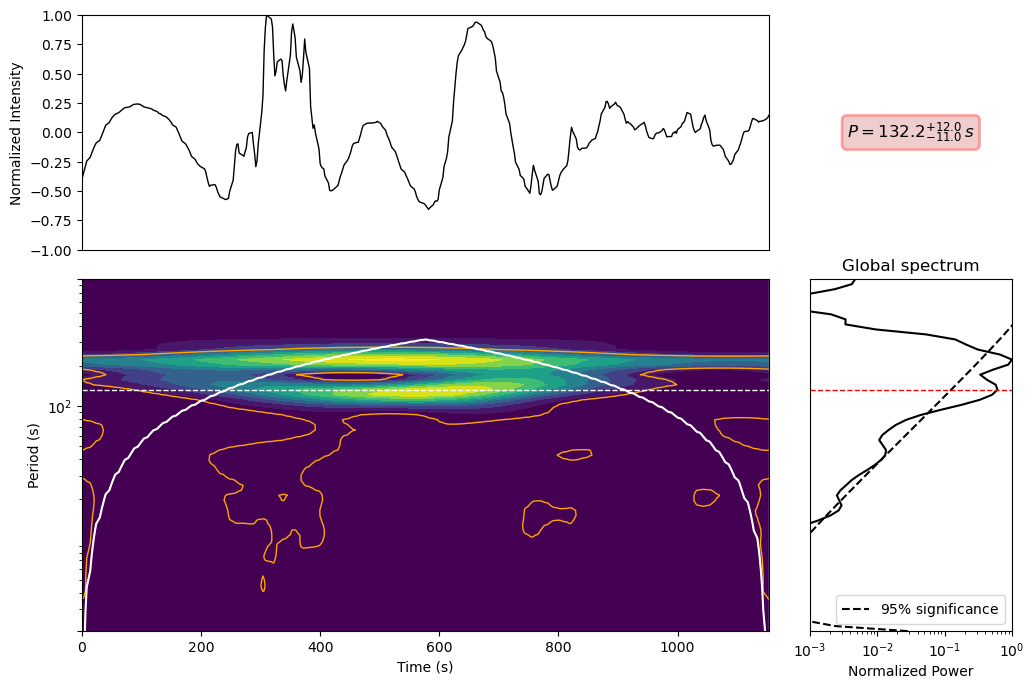

In [614]:
eui = eui_lcs_t['kernel_04_07']
P0, err_low, err_high, fig = wavelet_analysis(eui, dj=0.125,
                                detrend=True, peak_method='ratio_ridge',
                                detrend_method='savgol')
# results = analyze_flare_phases(eui, time_ranges, phase_names)

--- 

#### GOES derivative ($1-8\,\rm Å$):

#### - wavelet analysis with detrending

---

In [598]:
# goes = goes_lc_t
# P0, err_low, err_high, fig = wavelet_analysis(goes, dj=0.0625,
#                                detrend=True, peak_method='ratio_ridge',
#                                detrend_method='savgol')
# results = analyze_flare_phases(goes, time_ranges, phase_names)

--- 

#### Fermi GBM ($25-50\,\rm keV$):

#### - wavelet analysis with detrending

---

In [607]:
# fermi = fermi_lc_t
# P0, err_low, err_high, fig = wavelet_analysis(fermi, dj=0.001,
#                                detrend=True, peak_method='ratio_ridge',
#                                detrend_method='savgol')
# results = analyze_flare_phases(fermi, time_ranges, phase_names)

### $\color{red}{\text{8. Determination of the periodicities - LOMB SCARGLE PERIODOGRAM}} $
---

#### Here, we estimate periodicities by using Lomb-Scargle periodogram.

In [620]:
def lomb_scargle_analysis(series, min_period=30, max_period=300):
    t = (series.index - series.index[0]).total_seconds().values
    y = series.values
    
    frequency = np.linspace(1/max_period, 1/min_period, 1000)
    ls = LombScargle(t, y)
    power = ls.power(frequency)
    
    period = 1/frequency
    best_period = period[np.argmax(power)]

    plt.figure(figsize=(12, 5))
    plt.plot(period, power)
    plt.xlabel('Period (s)')
    plt.xscale('log')
    plt.xticks([100, 1000])
    plt.ylabel('Lomb-Scargle Power')
    plt.axvline(best_period, color='red', label=f'Peak: {best_period:.1f} s')
    plt.legend()
    plt.show()
    
    return best_period, period, power

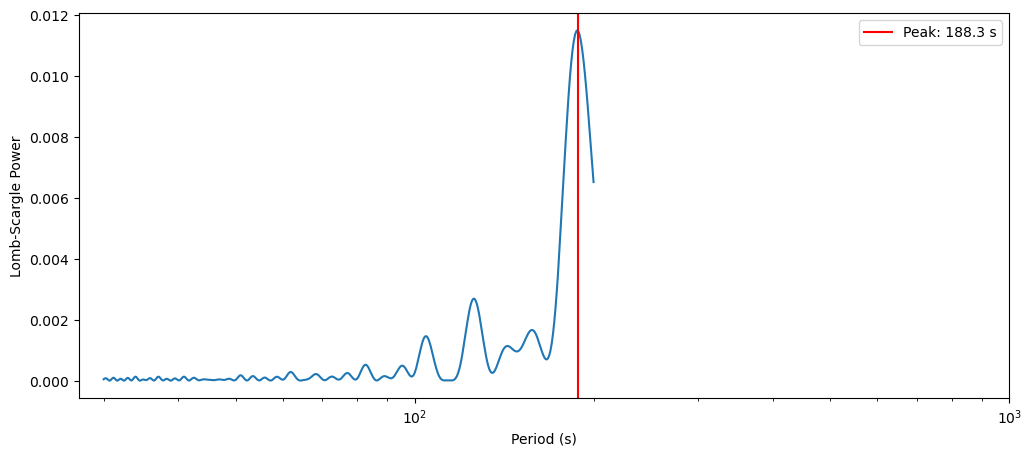

In [621]:
results = lomb_scargle_analysis(stix_25_50, 30, 200)

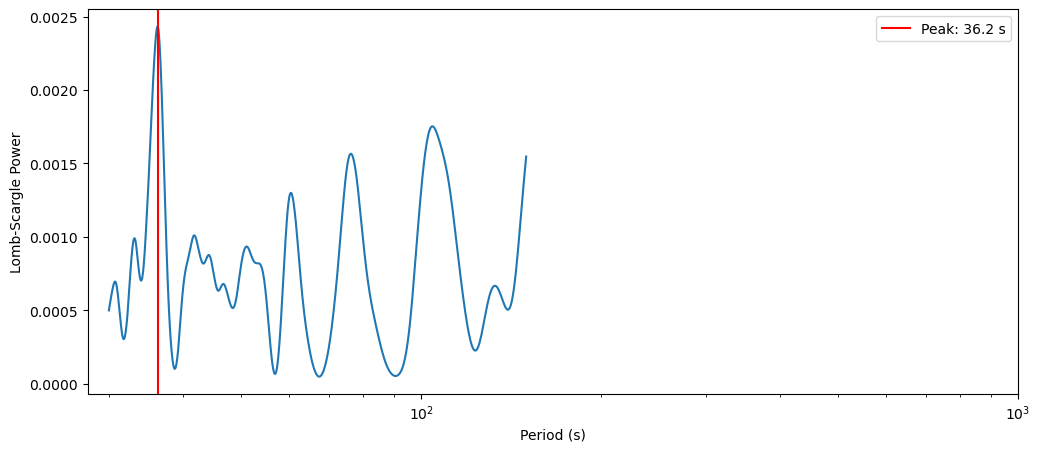

In [625]:
results = lomb_scargle_analysis(goes, 30, 150)

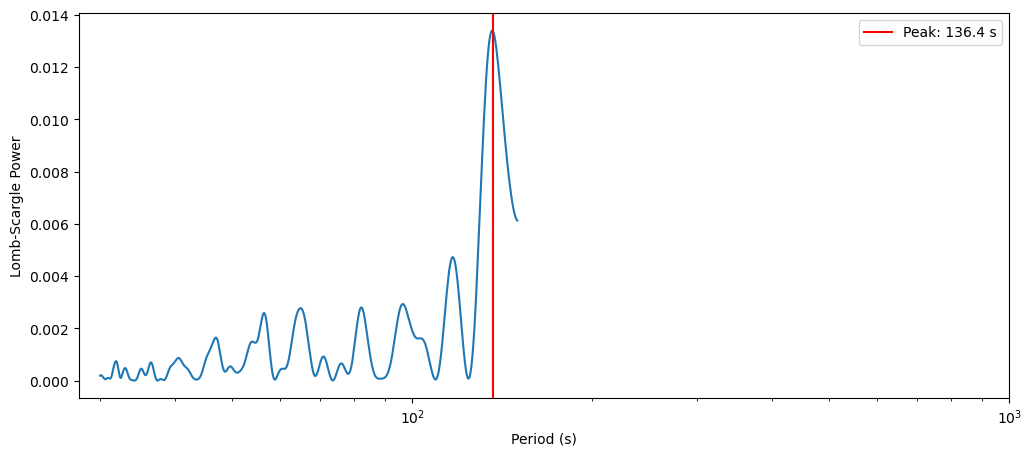

In [624]:
results = lomb_scargle_analysis(eui, 30, 150)

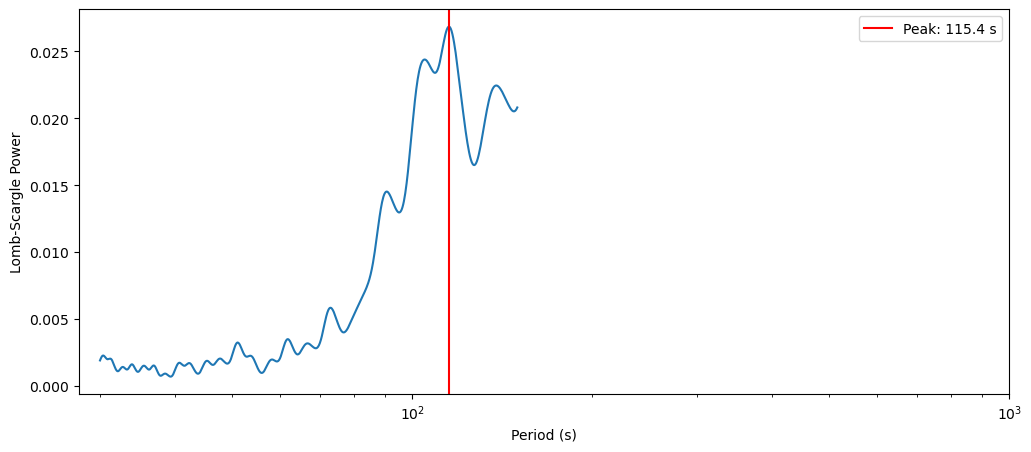

In [628]:
results = lomb_scargle_analysis(fermi, 30, 150)

### $\color{red}{\text{9. Determination of the periodicities - ALTERNATIVE}} $
---

#### Here, we estimate periodicities manually by visually identifying peaks. 

#### Firstly, we check cadence in order to determine best *distance* and *prominence*.

In [664]:
def check_cadence(series, name):
    time_diffs = series.index.to_series().diff().dropna()
    median_cadence = time_diffs.median()
    mean_cadence = time_diffs.mean()
    min_cadence = time_diffs.min()
    max_cadence = time_diffs.max()
    
    print(f"\n{name} cadence - basic statistics:")
    print(f"Median: {median_cadence.total_seconds():.2f} s")
    print(f"Mean: {mean_cadence.total_seconds():.2f} s")
    print(f"Minimum: {min_cadence.total_seconds():.2f} s")
    print(f"Maximum: {max_cadence.total_seconds():.2f} s")
    print(f"Total points: {len(series)}")
    print(f"Duration: {(series.index[-1] - series.index[0]).total_seconds():.1f} s")
    
    return median_cadence.total_seconds()

cadences = {}
cadences['STIX'] = check_cadence(stix_25_50, 'STIX 25-50 keV')
cadences['EUI'] = check_cadence(eui, 'EUI HRIEUV')
cadences['Fermi'] = check_cadence(fermi, 'Fermi GBM')
cadences['GOES'] = check_cadence(goes, 'GOES derivative')


STIX 25-50 keV cadence - basic statistics:
Median: 3.00 s
Mean: 3.16 s
Minimum: 2.90 s
Maximum: 6.00 s
Total points: 381
Duration: 1199.2 s

EUI HRIEUV cadence - basic statistics:
Median: 2.00 s
Mean: 2.67 s
Minimum: 1.77 s
Maximum: 6.07 s
Total points: 434
Duration: 1154.0 s

Fermi GBM cadence - basic statistics:
Median: 1.60 s
Mean: 1.60 s
Minimum: 1.60 s
Maximum: 1.60 s
Total points: 751
Duration: 1200.0 s

GOES derivative cadence - basic statistics:
Median: 2.00 s
Mean: 2.00 s
Minimum: 2.00 s
Maximum: 2.00 s
Total points: 601
Duration: 1200.0 s


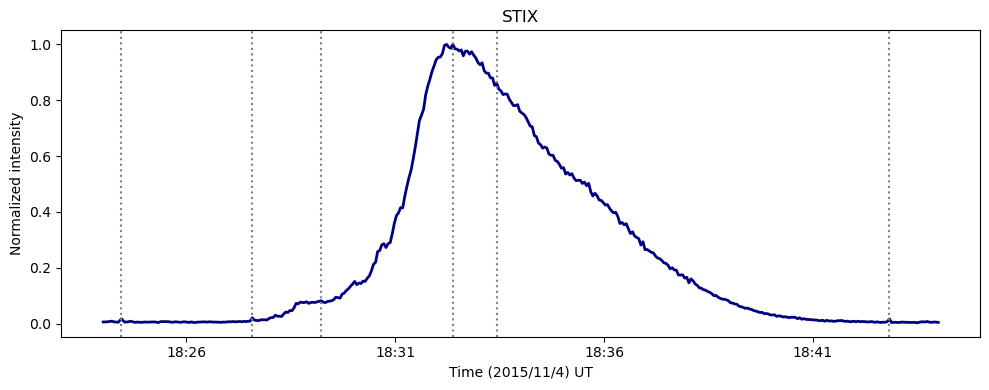

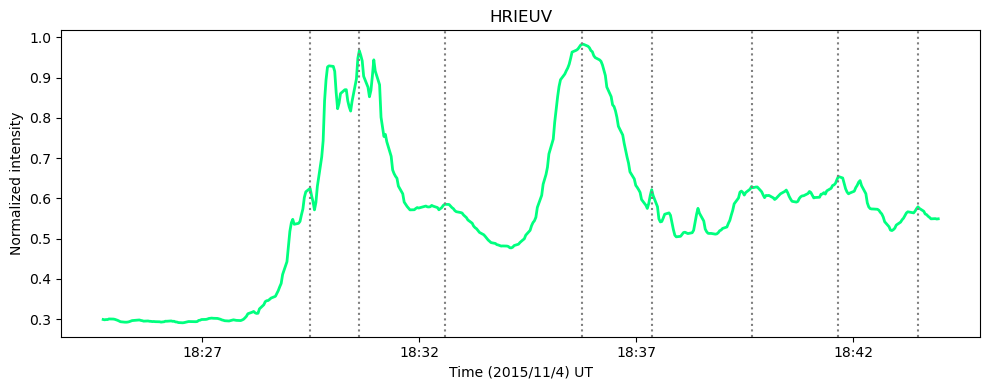

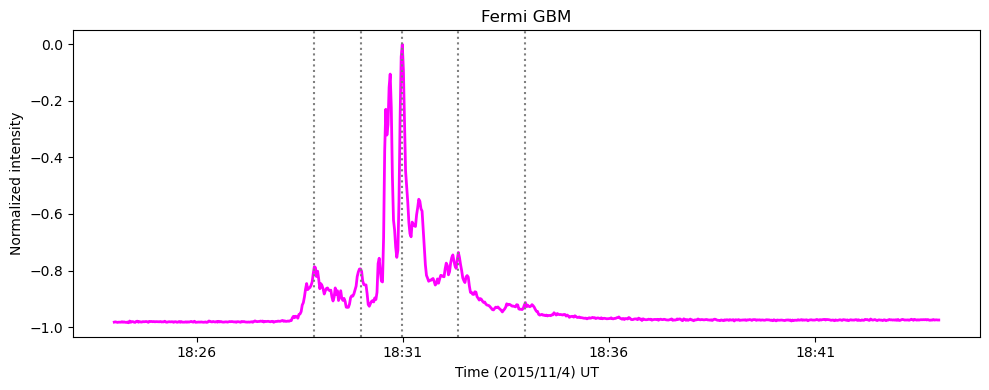

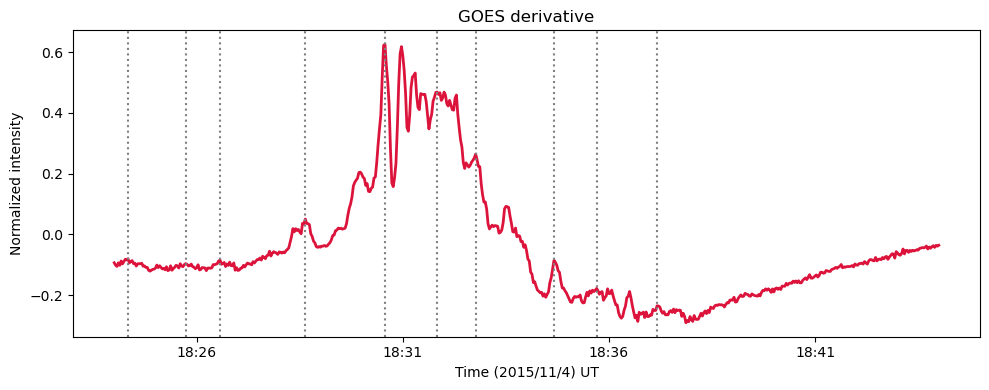

In [667]:
instruments = {
        'STIX': {
        'series': stix_25_50,
        'color': 'navy',
        'distance': max(1, int(50 / cadences['STIX'])),     
        'prominence': 0.006},
    'HRIEUV': {
        'series': eui,
        'color': 'springgreen',
        'distance': max(1, int(50 / cadences['EUI'])),      
        'prominence': 0.01},
    'Fermi GBM': {
        'series': fermi,
        'color': 'magenta',
        'distance': max(1, int(50 / cadences['Fermi'])),     
        'prominence': 0.03},
    'GOES derivative': {
        'series': goes,
        'color': 'crimson',
        'distance': max(1, int(50 / cadences['GOES'])),      
        'prominence': 0.02}}

results = {}
for label, cfg in instruments.items():
    series = cfg['series']
    dist, prom = cfg['distance'], cfg['prominence']
    color = cfg['color']
    
    peaks, props = find_peaks(series.values, distance=dist, prominence=prom)
    proms = props['prominences']

    top = np.argsort(proms)[-10:]
    idxs = np.sort(peaks[top])
    peak_times = series.index[idxs]

    pulse_num = np.arange(1, len(idxs)+1)
    tsec = (peak_times - peak_times[0]).total_seconds()
    P, t0 = np.polyfit(pulse_num, tsec, 1)

    results[label] = {
        'pulse_num': pulse_num,
        'tsec': tsec,
        'P': P,
        't0': t0,
        'peak_times': peak_times}

    plt.figure(figsize=(10,4))
    plt.plot(series.index, series, color=color, lw=2)
    for t in peak_times:
        plt.axvline(t, color='grey', ls=':')
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
    plt.xlabel('Time (2015/11/4) UT')
    plt.ylabel('Normalized intensity')
    plt.title(f'{label}')
    plt.tight_layout()
    plt.savefig(f'{label}')
    plt.show()

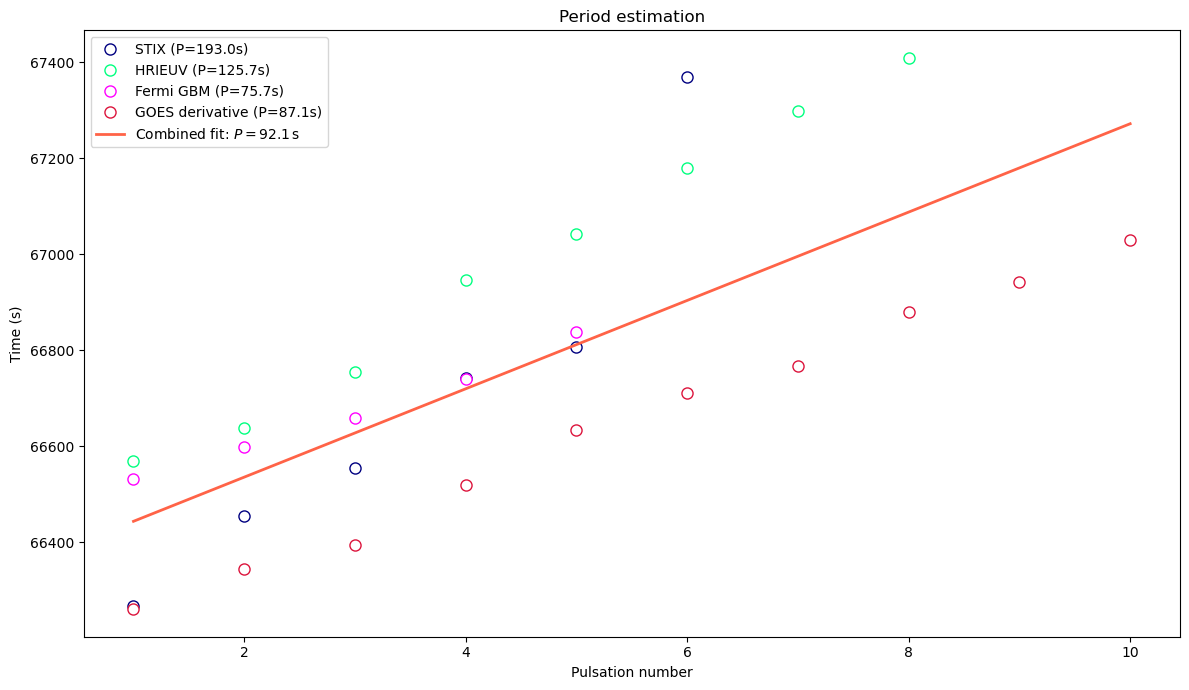

In [666]:
first_peaks = [cfg['peak_times'][0] for cfg in results.values()]
day0 = min(first_peaks).normalize()

plt.figure(figsize=(12,7))

for label, cfg in instruments.items():
    pulse_num  = results[label]['pulse_num']
    peak_times = results[label]['peak_times']
    t_abs = (peak_times - day0).total_seconds()
    color = cfg['color']
    P_inst = results[label]['P']
    
    plt.plot(pulse_num, t_abs,'o', ms=8, mfc='white', mec=color, 
             label=f'{label} (P={P_inst:.1f}s)')
    
all_i = np.hstack([results[L]['pulse_num'] for L in results])
all_t = np.hstack([(results[L]['peak_times'] - day0).total_seconds() for L in results])
P, t0 = np.polyfit(all_i, all_t, 1)

i_vals = np.arange(1, int(all_i.max())+1)
plt.plot(i_vals, P*i_vals + t0,
         '-', lw=2, color='tomato',
         label=rf'Combined fit: $P={P:.1f}\,$s')

plt.xlabel('Pulsation number')
plt.ylabel('Time (s)')
plt.title('Period estimation')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('sfi_17.png')
plt.show()

#### Our period might have harmonics, so we can check that. But this is pure approximation

#### for now! We may analyse this further, in future work.

In [629]:
harmonic_ranges = [
    (40, 50), # ~ P/2   
    (85, 95), # ~ P 
    (170, 190)] # ~ 2P

for p_min, p_max in harmonic_ranges:
    print(f"\nSearching {p_min}-{p_max}s range:")
    min_distance = int(p_min / cadences['GOES'])
    
    peaks, props = find_peaks(goes.values, 
                             distance=min_distance, 
                             prominence=0.01)
    if len(peaks) >= 3:
        print(f"  Found {len(peaks)} peaks")


Searching 40-50s range:
  Found 19 peaks

Searching 85-95s range:
  Found 10 peaks

Searching 170-190s range:
  Found 5 peaks
